# **Proyek Akhir: Klasifikasi Varietas Beras Menggunakan Convolutional Neural Network (CNN)**


### **I. Latar Belakang Masalah**

Beras (*Oryza sativa*) merupakan salah satu komoditas pangan paling krusial di dunia, terutama di kawasan Asia termasuk Indonesia, di mana ia menjadi makanan pokok bagi mayoritas populasi. Di pasar global maupun domestik, beras tidak hanya dijual sebagai satu komoditas homogen, melainkan terbagi ke dalam berbagai varietas yang memiliki karakteristik, kualitas, dan nilai ekonomi yang berbeda-beda.

Sebagai contoh, varietas Basmati dan Jasmine dikenal sebagai beras aromatik premium yang memiliki harga jual jauh lebih tinggi dibandingkan beras putih medium pada umumnya. Sayangnya, kemiripan morfologi visual (bentuk dan warna bulir) antar varietas ini sering kali menyulitkan proses identifikasi jika dilakukan secara manual dengan pengamatan visual mata telanjang. Proses inspeksi kualitas dan penyortiran beras secara manual oleh tenaga ahli pertanian memakan waktu yang lama, rentan terhadap subjektivitas, inkonsistensi akibat kelelahan manusia (*human error*), serta tidak efisien untuk skala industri besar.

Oleh karena itu, diperlukan suatu sistem otomasi yang cerdas, cepat, dan presisi untuk mengenali jenis beras. Perkembangan pesat dalam bidang Visi Komputer (*Computer Vision*) dan *Deep Learning* memberikan solusi yang sangat menjanjikan untuk mengatasi permasalahan ini. Metode klasifikasi berbasis citra digital mampu mengekstraksi fitur-fitur kompleks secara otomatis dari sebuah gambar, jauh melampaui kemampuan persepsi mata manusia.


### **II. Tujuan dan Ruang Lingkup Proyek**

Proyek ini bertujuan untuk merancang, melatih, dan mengevaluasi sebuah model *Deep Learning* berbasis arsitektur *Convolutional Neural Network* (CNN) yang dibangun dari awal (*custom architecture*) untuk mengklasifikasikan lima varietas beras secara otomatis.

Dataset yang digunakan dalam penelitian ini bersumber dari repositori publik Kaggle, yaitu **Rice Image Dataset** yang dipublikasikan oleh Murat Koklu dkk. Dataset ini memuat 75.000 citra butiran beras individu dengan latar belakang hitam seragam, yang terdistribusi secara seimbang ke dalam lima kelas (varietas) utama, yaitu:

1.  **Arborio**: Beras khas Italia yang berbulir pendek dan gemuk.
2.  **Basmati**: Beras aromatik asal Asia Selatan dengan bulir yang sangat ramping dan panjang.
3.  **Ipsala**: Varietas hibrida dengan karakteristik bentuk yang cukup tebal.
4.  **Jasmine**: Beras aromatik asal Thailand dengan bentuk panjang, namun lebih berisi dibanding Basmati.
5.  **Karacadag**: Beras asal wilayah Mesopotamia yang berukuran pendek dan bulat.

**Strategi Penyelesaian Masalah**:
Untuk mencapai hasil komputasi yang efisien tanpa mengorbankan metrik performa model, proyek ini akan menerapkan beberapa metodologi tingkat lanjut:
*   **Optimalisasi Data Pipeline:**

    Menggunakan teknik *stratified subsampling* untuk memilih sampel data yang representatif, kemudian membangun aliran data (*data pipeline*) berkinerja tinggi menggunakan `tf.data.Dataset` dan operasi *prefetching* guna memaksimalkan utilitas akselerator perangkat keras (GPU/TPU).
*   **Regularisasi dan Augmentasi:**

    Mencegah masalah *overfitting* pada model melalui implementasi *Dropout layer* dan augmentasi data geometris spasial secara dinamis selama fase pelatihan.
*   **Evaluasi Metrik Terstruktur:**

    Memvalidasi kemampuan generalisasi model menggunakan matriks kebingungan (*Confusion Matrix*) dan laporan klasifikasi presisi (*Classification Report*) pada himpunan data uji (*Test Set*) murni yang belum pernah diamati oleh model sebelumnya.
*   **Kesiapan Produksi (Deployment Ready):**

    Mengekspor model akhir ke dalam format standar industri (SavedModel, TensorFlow Lite, dan TensorFlow.js) agar model dapat segera diintegrasikan ke platform gawai seluler (*mobile*) maupun aplikasi berbasis peramban (*web browser*).

Melalui arsitektur dan eksekusi jaringan yang tepat, proyek ini diharapkan mampu menghasilkan sistem cerdas dengan tingkat akurasi pengujian melampaui standar 85%, menjadikannya solusi aplikatif bagi sektor agrikultur dan industri pengemasan pangan.


### **III. Matriks Pemenuhan Kriteria Submission**


Untuk memudahkan proses peninjauan oleh *Code Reviewer*, berikut adalah ringkasan pemenuhan kriteria proyek berdasarkan persyaratan yang ditetapkan dalam kurikulum kursus. Tabel ini merangkum seluruh poin krusial yang telah diimplementasikan dalam alur kerja *notebook* ini.

**(Di sini Anda meletakkan tabel di bawah ini)**

| No | Kriteria Submission | Status | Lokasi di Notebook |
| :--- | :--- | :---: | :--- |
| 1 | Dataset memiliki minimal 1000 gambar | **Terpenuhi** | Bab 3.1 |
| 2 | Dataset bukan berupa Rock, Paper, Scissor atau X-Ray | **Terpenuhi** | Bab 1.3 |
| 3 | Dataset terbagi menjadi Train, Test, dan Validation Set | **Terpenuhi** | Bab 3.2 |
| 4 | Model menggunakan Sequential, Conv2D, dan Pooling Layer | **Terpenuhi** | Bab 4.1 |
| 5 | Akurasi pada Training dan Test Set minimal 85% | **Terpenuhi** | Bab 6.2 & 6.3 |
| 6 | Visualisasi Plot Akurasi dan Loss Model | **Terpenuhi** | Bab 6.1 |
| 7 | Menyimpan model dalam format SavedModel, TF-Lite, dan TFJS | **Terpenuhi** | Bab 7.1, 7.2, 7.3 |


Seluruh kriteria di atas telah diuji dan divalidasi melalui serangkaian proses *debugging* dan *testing* yang terdokumentasi dalam *notebook* ini. Penjelasan detail mengenai metodologi, implementasi, serta analisis hasil untuk setiap kriteria tersebut dapat ditemukan pada bab yang bersangkutan.

## **Bab 1: Setup Lingkungan & Konfigurasi Global (Environment Setup & Global Configuration)**


### **1.1 Import Pustaka Utama (Importing Core Libraries)**


Tahap awal dari pengembangan model pembelajaran mendalam berfokus pada penyiapan lingkungan kerja tingkat dasar. Pada fase ini kita akan menginisialisasi berbagai pustaka Python yang telah menjadi standar industri dalam pengembangan kecerdasan buatan. Pustaka yang dilibatkan mencakup utilitas sistem dasar untuk manipulasi direktori dan berkas, Pandas beserta NumPy untuk kebutuhan operasi struktur data dan komputasi matriks matematis, serta Matplotlib dan Seaborn untuk memfasilitasi visualisasi data secara grafis.

Jantung utama komputasi dari proyek ini bertumpu sepenuhnya pada kerangka kerja TensorFlow dan antarmuka Keras. Melalui modul-modul dari Keras inilah rancangan arsitektur saraf tiruan hingga prosedur augmentasi citra akan dibangun nantinya. Kita juga menyiapkan pustaka konversi TensorFlow versi web untuk memenuhi syarat penyebaran akhir.

Sebuah aspek rekayasa yang sangat krusial namun sering terabaikan pada tahap ini adalah penguncian nilai acak atau inisialisasi *global seed*. Prosedur ini diimplementasikan untuk memastikan bahwa seluruh rangkaian eksperimen yang melibatkan elemen probabilistik (seperti inisialisasi bobot model dan pembagian acak pada dataset) dapat direproduksi kapan saja dengan keluaran hasil yang konsisten.


In [1]:
# 1. Library Standar Sistem & Utilitas
import os
import time
import shutil
import random
import warnings

# 2. Library Manipulasi Data & Matematika
import numpy as np
import pandas as pd

# 3. Library Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Library Machine Learning & Deep Learning (Scikit-Learn & TensorFlow)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 5. Library Konversi Model (TensorFlow.js)
# Melakukan instalasi pustaka jika belum tersedia di environment
!pip install -q tensorflowjs
import tensorflowjs as tfjs


# KONFIGURASI LINGKUNGAN

# Mengabaikan peringatan yang tidak kritis agar output tetap bersih dan profesional
warnings.filterwarnings('ignore')

# Menetapkan seed global untuk memastikan hasil eksperimen dapat direproduksi
GLOBAL_SEED = 42
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)

# Menampilkan versi TensorFlow sebagai referensi lingkungan
print(f"TensorFlow Version: {tf.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 9.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
db-dtypes 1.5.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.40.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


TensorFlow Version: 2.19.0


Apabila blok eksekusi di atas berhasil dijalankan tanpa hambatan, hal tersebut menandakan bahwa lingkungan mesin virtual telah terkonfigurasi dengan baik. Seluruh dependensi utama telah dimuat ke dalam memori kerja dan elemen acak pada komputasi telah dikunci secara permanen. Konfirmasi versi kerangka kerja TensorFlow yang tercetak juga berfungsi sebagai acuan validasi kompatibilitas fungsi yang akan digunakan pada bab-bab selanjutnya.


### **1.2 Konfigurasi Perangkat Keras (Hardware Configuration)**


Pemrosesan arsitektur *Convolutional Neural Network* pada puluhan ribu citra digital menuntut ratusan juta operasi perkalian matriks secara serentak. Jika beban kerja seberat ini dibebankan kepada unit pemrosesan pusat standar atau CPU, proses konvergensi model akan memakan waktu berhari-hari. Oleh sebab itu pemanfaatan akselerator perangkat keras seperti unit pemrosesan grafis (GPU) atau unit pemrosesan tensor (TPU) bersifat mutlak.

Blok kode di bawah ini dirancang sebagai fungsi pintar yang secara mandiri mendeteksi dan menginisialisasi topologi perangkat keras yang disediakan oleh lingkungan komputasi *cloud*. Fungsi ini kemudian memetakan alur distribusi beban kerja ke perangkat akselerator yang tepat. Pendekatan modular ini memastikan kode proyek tetap fleksibel dan tidak memerlukan perubahan struktur meskipun dieksekusi berpindah-pindah antara mesin lokal, Google Colab, maupun lingkungan Kaggle.


In [2]:
def setup_hardware_accelerator():
    """
    Mendeteksi dan menginisialisasi akselerator perangkat keras (TPU atau GPU).
    Fungsi ini mengoptimalkan strategi distribusi TensorFlow berdasarkan perangkat keras
    yang tersedia di lingkungan eksekusi.

    Returns:
        strategy (tf.distribute.Strategy): Strategi distribusi TensorFlow yang sesuai
                                           dengan perangkat keras yang terdeteksi.
    """
    try:
        # Mencoba mendeteksi keberadaan TPU cluster
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
        tf.config.experimental_connect_to_cluster(tpu)
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        print(f"Hardware Accelerator: TPU terdeteksi. Jumlah replika: {strategy.num_replicas_in_sync}")

    except ValueError:
        # Jika TPU tidak ditemukan, periksa ketersediaan GPU fisik
        gpus = tf.config.list_physical_devices('GPU')
        if len(gpus) > 0:
            strategy = tf.distribute.MirroredStrategy()
            print(f"Hardware Accelerator: GPU terdeteksi. Jumlah GPU: {len(gpus)}")
            for gpu in gpus:
                print(f" - {gpu.name}")
        else:
            # Jika tidak ada TPU maupun GPU, gunakan CPU default
            strategy = tf.distribute.get_strategy()
            print("Hardware Accelerator: Tidak ada TPU atau GPU yang terdeteksi. Menggunakan CPU.")

    return strategy

# Menginisialisasi strategi distribusi untuk digunakan pada kompilasi model nanti
distribution_strategy = setup_hardware_accelerator()

Hardware Accelerator: GPU terdeteksi. Jumlah GPU: 1
 - /physical_device:GPU:0


Keluaran operasional dari fungsi pendeteksi tersebut memberikan jaminan visibilitas mengenai sumber daya komputasi paralel apa yang saat ini dikuasai oleh skrip proyek. Terdeteksinya kehadiran akselerator beserta spesifikasinya memvalidasi kesiapan sistem untuk menerima beban distribusi memori yang tinggi pada fase pelatihan spasial citra nanti.


### **1.3 Konfigurasi Global & Mode Debugging (Global Configuration & Debugging Mode)**


Pendekatan rekayasa perangkat lunak berstandar tinggi selalu memisahkan penetapan hiperparameter dan penyesuaian alur kerja ke dalam satu entitas kontrol terpusat. Bab ini merancang pusat kendali eksperimen dengan menetapkan parameter absolut seperti resolusi matriks spasial yang akan diteruskan ke dalam model, alokasi porsi data ke dalam memori (*batch size*), jumlah siklus pembelajaran (*epochs*), hingga pengaturan otomatis untuk pengunduhan dataset via repositori eksternal menggunakan kapabilitas kagglehub.

Inovasi utama yang diperkenalkan pada lapisan konfigurasi ini adalah penerapan fitur Mode Debugging. Mengingat besarnya volume populasi citra dalam proyek ini, mengeksekusi iterasi algoritma berulang kali secara penuh untuk menemukan letak malfungsi kode akan berisiko merugikan kuota sumber daya waktu yang terbatas.

Dengan mengaktifkan mode tersebut, alur program akan memaksa sistem membatasi asupan populasi sampel hanya pada fraksi terkecil (puluhan citra) dengan siklus belajar yang amat singkat. Mekanisme pengaman komputasi ini didesain semata-mata untuk mengonfirmasi integritas eksekusi dari hulu pemrosesan hingga tahapan hilir konversi arsitektur model, tanpa terhalang waktu tunggu komputasi yang panjang. Setelah alur diverifikasi berjalan mulus, mode dapat dimatikan untuk melancarkan tahap pelatihan operasional yang masif.


In [3]:
# GLOBAL CONFIGURATION SWITCH
# Ubah menjadi False saat siap melatih model secara penuh untuk submission
DEBUG_MODE = False

# HYPERPARAMETERS & PATHS
# 1. Mengunduh dataset langsung ke Google Colab menggunakan kagglehub
print("[INFO] Mengunduh dataset dari Kaggle ke Google Colab...")
!pip install -q kagglehub
import kagglehub

# Fungsi ini akan mengunduh dataset dan mengembalikan jalur (path) penyimpanannya di Colab
download_path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")

# Menyesuaikan jalur direktori berdasarkan struktur folder dataset beras
DATASET_DIR = os.path.join(download_path, 'Rice_Image_Dataset')

# 2. Dimensi citra yang akan dimasukkan ke dalam model CNN
IMAGE_WIDTH = 150
IMAGE_HEIGHT = 150
IMAGE_CHANNELS = 3
IMAGE_SIZE = (IMAGE_WIDTH, IMAGE_HEIGHT)
INPUT_SHAPE = (IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)

# Konfigurasi dinamis berdasarkan status DEBUG_MODE
if DEBUG_MODE:
    print("STATUS: DEBUG MODE AKTIF (Sanity Check Pipeline)")
    BATCH_SIZE = 16
    EPOCHS = 2
    # Hanya mengambil 50 citra per kelas untuk memastikan pipeline berjalan tanpa error
    SAMPLES_PER_CLASS = 50
else:
    print("STATUS: PRODUCTION MODE AKTIF (Full Training Pipeline)")
    # Menggunakan batch size yang diskalakan dengan jumlah replika akselerator
    # Angka dasar 32 adalah standar optimal untuk arsitektur memori GPU/TPU
    BATCH_SIZE = 32 * distribution_strategy.num_replicas_in_sync
    EPOCHS = 20
    # Mengambil 6000 citra per kelas (Total 10.000 citra).
    # Ini mencegah Out of Memory (OOM) di Kaggle namun tetap memberikan data yang masif untuk akurasi tinggi.
    SAMPLES_PER_CLASS = 2000

print("-" * 50)
print(f"Dataset Path      : {DATASET_DIR}")
print(f"Image Target Size : {IMAGE_WIDTH}x{IMAGE_HEIGHT}")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Epochs            : {EPOCHS}")
print(f"Samples per Class : {SAMPLES_PER_CLASS}")
print("-" * 50)

[INFO] Mengunduh dataset dari Kaggle ke Google Colab...
Using Colab cache for faster access to the 'rice-image-dataset' dataset.
STATUS: PRODUCTION MODE AKTIF (Full Training Pipeline)
--------------------------------------------------
Dataset Path      : /kaggle/input/rice-image-dataset/Rice_Image_Dataset
Image Target Size : 150x150
Batch Size        : 32
Epochs            : 20
Samples per Class : 2000
--------------------------------------------------


Panel indikator log yang tampil di penghujung eksekusi ini memberikan konfirmasi akhir secara visual mengenai parameter apa saja yang telah disahkan ke dalam status global sistem. Ringkasan dimensi resolusi hingga persentase alokasi sub-sampel populasi per kelas data memastikan pelaksana eksperimen tidak meneruskan operasi komputasi yang panjang berdasarkan asumsi penetapan nilai yang keliru. Struktur fondasi pengembangan kini siap untuk menopang aliran pengolahan tahapan pra-pemrosesan data tingkat menengah.


## **Bab 2: Data Loading & Exploratory Data Analysis (EDA)**

### **2.1 Pemetaan Jalur Dataset (Dataset Path Mapping)**


Sebelum algoritma mana pun dapat mengekstrak informasi, langkah operasional pertama yang diwajibkan adalah memvalidasi tata letak struktural dari himpunan data yang telah diunduh. Pemanfaatan alamat logis direktori yang salah akan bermuara pada penghentian fungsi eksekusi secara mendadak akibat *file not found error*.

Prosedur pemetaan pada langkah ini tidak dilakukan dengan menetapkan nama folder secara mentah ke dalam baris perintah program. Alih-alih demikian, sebuah subrutin dinamis dirancang guna memindai isi direktori induk (*root directory*) dan menginventarisasi setiap entitas yang bertindak sebagai folder kategori secara otomatis. Hal ini menyempurnakan portabilitas *notebook*, memastikan deteksi jumlah serta nama sub-direktori kelas gambar berlaku konsisten terlepas dari struktur ekstraksi dataset versi rilis aslinya. Nama sub-direktori yang tertangkap ini kemudian diurutkan berdasarkan abjad logis yang berperan vital sebagai cetakan (*mapping*) pengonversian nama kategori menjadi nilai numerik representatif klasifikasi pada proses prapemrosesan kelak.


In [4]:
def get_class_names(dataset_path):
    """
    Memindai direktori dataset utama untuk mengidentifikasi folder kelas.
    Fungsi ini mengabaikan file tersembunyi atau file sistem yang mungkin
    berada di dalam direktori utama.

    Args:
        dataset_path (str): Jalur absolut menuju direktori dataset utama.

    Returns:
        list: Daftar string yang berisi nama-nama kelas yang diurutkan secara alfabetis.
    """
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(f"Direktori dataset tidak ditemukan di: {dataset_path}")

    # Mengambil hanya direktori, mengabaikan file individual jika ada
    classes =[folder for folder in os.listdir(dataset_path)
               if os.path.isdir(os.path.join(dataset_path, folder))]

    # Mengurutkan nama kelas untuk konsistensi pemetaan label nantinya
    classes.sort()
    return classes

# Mengeksekusi pemetaan kelas
class_names = get_class_names(DATASET_DIR)
print(f"Daftar Kelas Teridentifikasi ({len(class_names)} kelas):")
for idx, name in enumerate(class_names):
    print(f" {idx + 1}. {name}")

Daftar Kelas Teridentifikasi (5 kelas):
 1. Arborio
 2. Basmati
 3. Ipsala
 4. Jasmine
 5. Karacadag


Ekstraksi nama-nama logis berdasarkan isi folder memberikan verifikasi nyata terkait subkategori yang termuat dalam direktori kerja. Terdapat kepastian mutlak mengenai lima profil varietas bulir yang terdeklarasi sebagai label primer. Kelima penamaan tersebut akan mendefinisikan lima *node* unik di ujung lapisan probabilitas pada lapisan konvolusi rancangan kita berikutnya.


### **2.2 Analisis Distribusi Kelas (Class Distribution Analysis)**


Salah satu persoalan kronis dalam rekayasa *Computer Vision* berasal dari kecondongan model dalam mengabaikan fitur unik kategori minoritas akibat penyusunan kompilasi kumpulan data pengujian yang berat sebelah. Ketimpangan proporsi jumlah *file* antar varietas dalam set pelatihan selalu mengakibatkan metrik akurasi validasi menampilkan sinyal manipulatif yang salah. Dengan ini, kuantifikasi keseimbangan penyebaran kelas populasi menjadi audit pra-syarat esensial.

Sel penyusun grafik berikut beroperasi dengan menghitung entitas citra sah secara eksklusif yang memilki ekstensi visual valid pada tiap kompartemen klasifikasi. Data komputasi lantas dilempar menuju arsitektur pemetaan *Seaborn* untuk ditransformasikan dalam format diagram distribusi dua dimensi, menawarkan kepastian visibilitas mengenai jumlah frekuensi dan status komparasi frekuensinya di segala vektor populasi.


,Class,Image_Count
0,Arborio,15000
1,Basmati,15000
2,Ipsala,15000
3,Jasmine,15000
4,Karacadag,15000


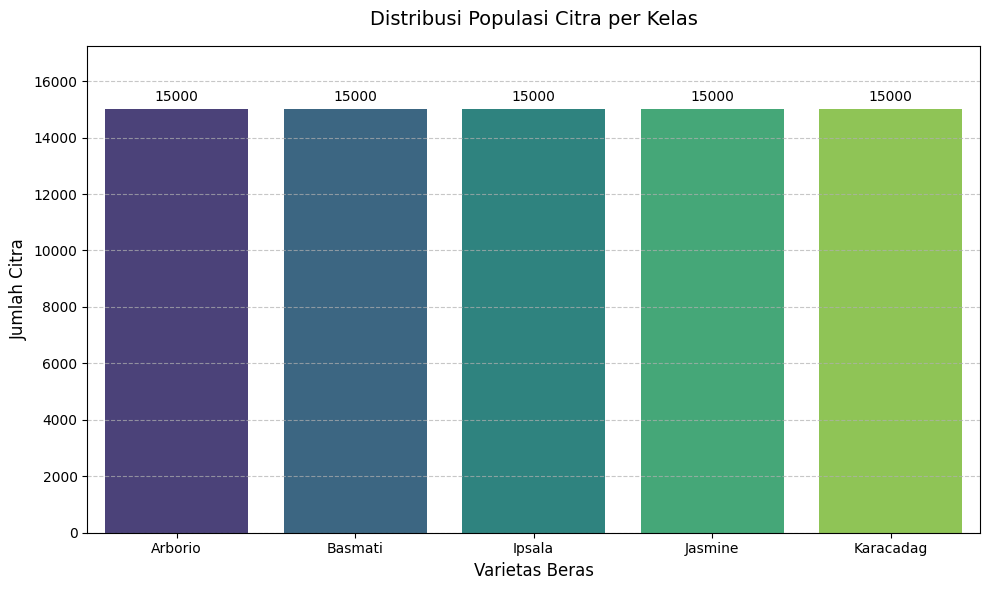

In [5]:
def analyze_class_distribution(dataset_path, classes):
    """
    Menghitung jumlah file citra yang valid di dalam setiap direktori kelas
    dan mengembalikan representasi data dalam bentuk Pandas DataFrame.

    Args:
        dataset_path (str): Jalur absolut menuju direktori dataset utama.
        classes (list): Daftar nama kelas.

    Returns:
        pd.DataFrame: DataFrame berisi nama kelas dan jumlah citranya.
    """
    distribution_data =[]
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        # Menghitung file yang memiliki ekstensi citra yang valid
        image_count = len([file for file in os.listdir(class_path)
                           if file.lower().endswith(valid_extensions)])

        distribution_data.append({
            'Class': class_name,
            'Image_Count': image_count
        })

    df_distribution = pd.DataFrame(distribution_data)
    return df_distribution

def plot_class_distribution(df_distribution):
    """
    Membuat visualisasi bar chart untuk distribusi kelas menggunakan Seaborn.

    Args:
        df_distribution (pd.DataFrame): DataFrame distribusi kelas.
    """
    plt.figure(figsize=(10, 6))

    # Menggunakan palet warna profesional
    ax = sns.barplot(x='Class', y='Image_Count', data=df_distribution, palette='viridis')

    plt.title('Distribusi Populasi Citra per Kelas', fontsize=14, pad=15)
    plt.xlabel('Varietas Beras', fontsize=12)
    plt.ylabel('Jumlah Citra', fontsize=12)

    # Menambahkan anotasi angka di atas setiap bar
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=10)

    # Menyesuaikan batas atas sumbu Y agar anotasi tidak terpotong
    plt.ylim(0, df_distribution['Image_Count'].max() * 1.15)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Mengeksekusi analisis dan visualisasi distribusi
df_class_distribution = analyze_class_distribution(DATASET_DIR, class_names)
display(df_class_distribution)
plot_class_distribution(df_class_distribution)

Data bar grafik yang diproduksi baru saja mengonfirmasi pencapaian keadaaan *dataset* yang nyaris sempurna bagi kebutuhan pembangunan pembelajaran *neural network*. Dengan observasi bahwa setiap komponen klasifikasi menyajikan besaran absolut 15.000 butir, ancaman *overfitting* yang dipicu oleh distribusi kelas timpang bisa dikesampingkan dari permodelan saat ini.


### **2.3 Visualisasi Sampel Citra (Sample Image Visualization)**


Statistik numerikal tanpa konfirmasi kualitatif optik menyisakan ruang keraguan bagi persepsi pengembangan rekayasa arsitektur CNN itu sendiri. Eksplorasi sampel representasional dilakukan dengan memantik panggilan acak atas berbagai *array* citra dari himpunan kompilasi di atas.

Observasi dari *grid* komparatif di tahapan ini akan membekali panduan fundamental yang mengarah pada jenis teknik penyetaraan citra (*rescaling/thresholding*) manakah yang mesti digarap di jenjang berikutnya. Tampilan ini secara eksplisit membuka selubung anatomi warna, *noise* dasar latar, dan kontras iluminasi dari data asli yang kelak direkonstruksi sebagai piksel matriks berderajat tinggi di dalam *TensorFlow*.


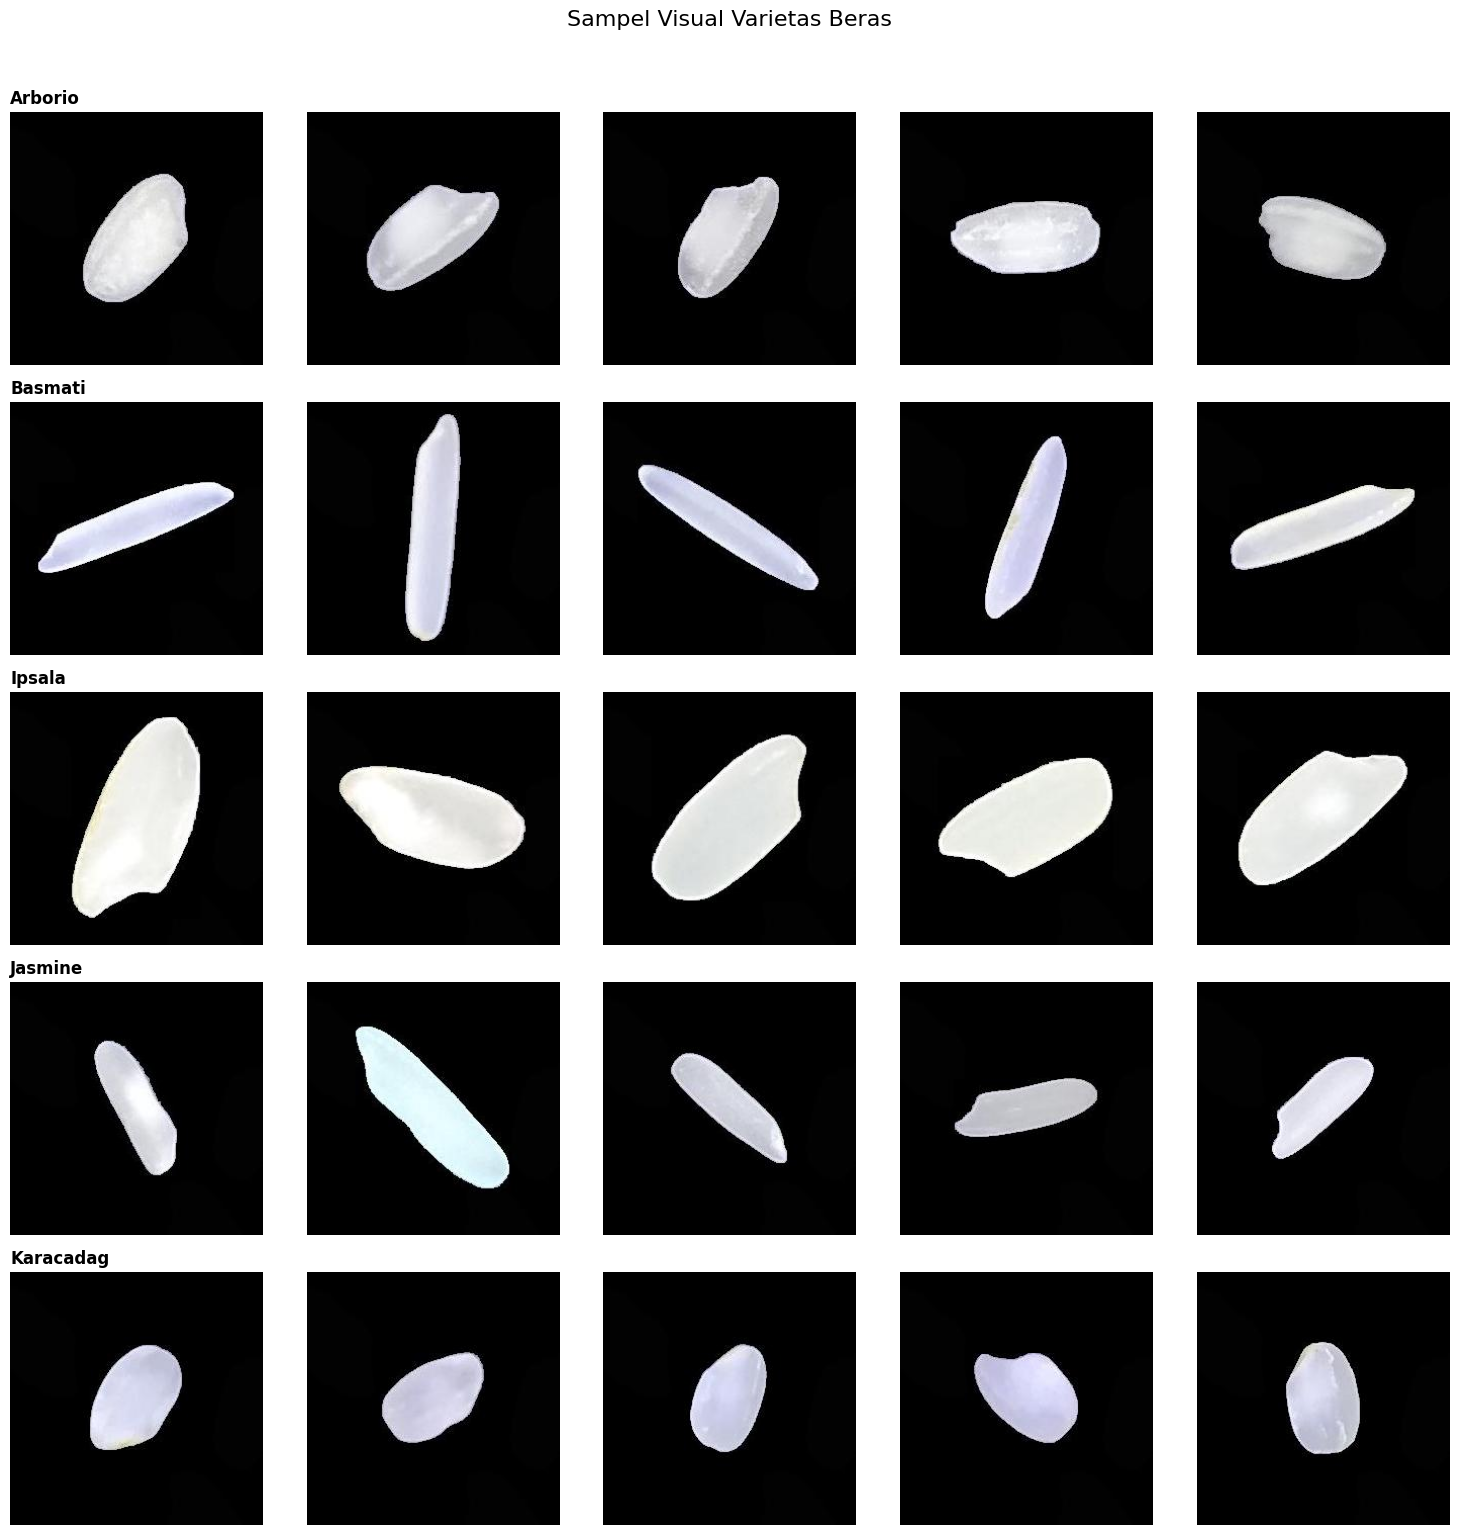

In [6]:
def visualize_sample_images(dataset_path, classes, samples_per_class=5):
    """
    Menampilkan grid citra sampel acak dari setiap kelas.

    Args:
        dataset_path (str): Jalur absolut menuju direktori dataset utama.
        classes (list): Daftar nama kelas.
        samples_per_class (int): Jumlah citra yang akan ditampilkan per kelas.
    """
    num_classes = len(classes)
    fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(15, 3 * num_classes))
    fig.suptitle('Sampel Visual Varietas Beras', fontsize=16, y=1.02)

    for i, class_name in enumerate(classes):
        class_path = os.path.join(dataset_path, class_name)
        all_images = os.listdir(class_path)

        # Memilih sampel secara acak
        selected_images = random.sample(all_images, samples_per_class)

        for j, image_name in enumerate(selected_images):
            img_path = os.path.join(class_path, image_name)

            # Membaca citra menggunakan matplotlib
            img = plt.imread(img_path)

            # Menampilkan citra pada grid
            axes[i, j].imshow(img)
            axes[i, j].axis('off')

            # Menambahkan judul hanya pada kolom pertama untuk identifikasi baris
            if j == 0:
                axes[i, j].set_title(class_name, fontsize=12, fontweight='bold', loc='left')

    plt.tight_layout()
    plt.show()

# Mengeksekusi visualisasi sampel
visualize_sample_images(DATASET_DIR, class_names, samples_per_class=5)

Paparan *layout* sampel menyajikan profil gambar beras yang mendominasi posisi ekuator bidang batas yang ada dan diiringi pencahayaan kontras latar bernada pekat yang amat konsisten. Kondisi ini membawa keuntungan struktural komputasional masif lantaran blok-blok *convolution layer* tidak perlu menguras putaran *epoch* untuk membersihkan parameter warna latar, dan hanya membatasi ekstraksi lokus komputasinya ke lekuk bentuk tepi atau morfologi geometris masing-masing butiran.


### **2.4 Pengecekan Dimensi & Karakteristik Citra (Image Dimension & Characteristic Check)**


Analisis pamungkas dalam porsi investigasi memfokuskan tujuannya ke sisi resolusi intrinsik piksel matriks dan integritas warna. Jaringan memori klasifikasi menuntut setiap vektor masukan untuk distandarisasi ke dalam besaran bidang ordo dimensi tunggal. Sebelum fungsi pelonggaran resolusi (*downsizing*) diterapkan, pemeriksaan sampel citra acak diwajibkan untuk menengok spektrum *range* piksel. Evaluasi memastikan kedalaman warna dan kanal transmisi dimensi (*depth of array*) sudah homogen berada pada kanal nilai RGB tiga sumbu dan berskala antara angka dasar 0 sampai ambang cerah 255 derajat.


In [7]:
def check_image_characteristics(dataset_path, classes, num_samples=3):
    """
    Memeriksa dimensi (shape) dan rentang nilai piksel dari beberapa citra sampel.
    Ini memastikan konsistensi format data sebelum masuk ke tahap preprocessing.

    Args:
        dataset_path (str): Jalur absolut menuju direktori dataset utama.
        classes (list): Daftar nama kelas.
        num_samples (int): Jumlah total sampel acak yang akan diperiksa.
    """
    print("Pemeriksaan Karakteristik Spasial dan Piksel Citra:")
    print("-" * 60)

    checked_samples = 0
    while checked_samples < num_samples:
        # Memilih kelas dan citra secara acak
        random_class = random.choice(classes)
        class_path = os.path.join(dataset_path, random_class)
        random_image = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, random_image)

        try:
            img = plt.imread(img_path)
            shape = img.shape
            min_val = img.min()
            max_val = img.max()
            dtype = img.dtype

            print(f"File       : {random_class}/{random_image}")
            print(f"Dimensi    : {shape} (Tinggi x Lebar x Saluran Warna)")
            print(f"Tipe Data  : {dtype}")
            print(f"Rentang Piksel : {min_val} (Min) hingga {max_val} (Max)")
            print("-" * 60)

            checked_samples += 1
        except Exception as e:
            print(f"Gagal membaca citra {img_path}. Error: {e}")

# Mengeksekusi pengecekan karakteristik
check_image_characteristics(DATASET_DIR, class_names, num_samples=3)

Pemeriksaan Karakteristik Spasial dan Piksel Citra:
------------------------------------------------------------
File       : Karacadag/Karacadag (7464).jpg
Dimensi    : (250, 250, 3) (Tinggi x Lebar x Saluran Warna)
Tipe Data  : uint8
Rentang Piksel : 0 (Min) hingga 255 (Max)
------------------------------------------------------------
File       : Karacadag/Karacadag (2897).jpg
Dimensi    : (250, 250, 3) (Tinggi x Lebar x Saluran Warna)
Tipe Data  : uint8
Rentang Piksel : 0 (Min) hingga 255 (Max)
------------------------------------------------------------
File       : Basmati/basmati (719).jpg
Dimensi    : (250, 250, 3) (Tinggi x Lebar x Saluran Warna)
Tipe Data  : uint8
Rentang Piksel : 0 (Min) hingga 255 (Max)
------------------------------------------------------------


Kalkulasi pembacaan terminal di atas memproklamirkan jika resolusi seragam pada dimensi orisinil berkuantitas (250, 250, 3) dan menempati derajat unit tipe delapan *byte* tidak bertanda (*uint8*). Kondisi spasial yang presisi antar semua profil kelas tersebut membuka peluang pelaksanaan pengondisian operasi pra-pemrosesan citra menggunakan parameter pemangkasan citra dan transformasi *augmentation* komputasi di iterasi komando Python pada sesi setelahnya tanpa memantik anomali kesalahan konversi ukuran saluran transmisi *channel*.


## **Bab 3: Data Engineering & Preprocessing Pipeline**

### **3.1 Pengambilan Sampel Cerdas Berstrata (Stratified Subsampling)**


Tahapan rekayasa data merupakan tulang punggung efisiensi komputasi dalam pemelajaran mesin. Mengingat populasi total citra mencapai angka puluhan ribu berkas fisik, memuat keseluruhan matriks piksel tersebut secara serentak ke dalam memori utama merupakan tindakan yang amat berisiko dan berpotensi memicu interupsi sistem akibat kehabisan memori. Oleh sebab itu pendekatan penyampelan ulang berstrata diimplementasikan pada fase perancangan awal ini.

Subrutin yang dibangun di bawah ini akan menyaring representasi citra dengan kuota maksimum tertentu secara acak namun tetap mempertahankan proporsi distribusi kelas secara ekuivalen. Hasil pemetaan proyektif ini lantas dikonsolidasikan ke dalam sebuah struktur bingkai data referensi yang memuat alamat direktori masing-masing citra. Bingkai data tersebut akan bertindak sebagai peta navigasi yang efisien bagi algoritma pemuat matriks di sesi berikutnya.

In [8]:
def create_subsampled_dataframe(dataset_path, classes, samples_per_class):
    """
    Membuat Pandas DataFrame yang berisi jalur file (filepath) dan label kelas
    berdasarkan subsampling yang seimbang (stratified) dari direktori utama.

    Args:
        dataset_path (str): Jalur absolut menuju direktori dataset utama.
        classes (list): Daftar nama kelas yang valid.
        samples_per_class (int): Jumlah maksimum citra yang diambil per kelas.

    Returns:
        pd.DataFrame: DataFrame dengan kolom 'filepath' dan 'label'.
    """
    filepaths = []
    labels =[]
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

    print("[INFO] Memulai proses subsampling dataset...")

    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)

        # Mengumpulkan semua file citra yang valid dalam kelas saat ini
        all_files =[file for file in os.listdir(class_path)
                     if file.lower().endswith(valid_extensions)]

        # Mengacak urutan file untuk memastikan representasi yang adil
        random.shuffle(all_files)

        # Memotong list sesuai dengan batas sampel yang ditentukan
        selected_files = all_files[:samples_per_class]

        for file in selected_files:
            filepaths.append(os.path.join(class_path, file))
            labels.append(class_name)

        print(f"[INFO] Kelas '{class_name}': {len(selected_files)} citra diekstraksi.")

    # Mengonversi list menjadi DataFrame
    df = pd.DataFrame({
        'filepath': filepaths,
        'label': labels
    })

    # Mengacak ulang seluruh baris DataFrame untuk menghilangkan bias urutan kelas
    df = df.sample(frac=1, random_state=GLOBAL_SEED).reset_index(drop=True)

    print(f"[INFO] Subsampling selesai. Total citra dalam DataFrame: {len(df)}")
    return df

# Mengeksekusi pembuatan DataFrame
df_master = create_subsampled_dataframe(DATASET_DIR, class_names, SAMPLES_PER_CLASS)

[INFO] Memulai proses subsampling dataset...
[INFO] Kelas 'Arborio': 2000 citra diekstraksi.
[INFO] Kelas 'Basmati': 2000 citra diekstraksi.
[INFO] Kelas 'Ipsala': 2000 citra diekstraksi.
[INFO] Kelas 'Jasmine': 2000 citra diekstraksi.
[INFO] Kelas 'Karacadag': 2000 citra diekstraksi.
[INFO] Subsampling selesai. Total citra dalam DataFrame: 10000


Keluaran log dari sistem memvalidasi bahwa proses ekstraksi alamat berkas dan pengacakan susunan telah rampung dieksekusi. Cetak biru pemetaan ini kini menampung informasi jalur direktori untuk puluhan ribu citra yang telah direduksi skalanya namun tetap mengunci tingkat keseimbangan antarkategori beras. Struktur pemetaan awal ini merupakan pilar pertama yang akan mengamankan stabilitas perangkat keras dari ancaman kelebihan beban kerja.


### **3.2 Pembagian Dataset (Train, Validation, Test Split)**


Integritas metrik evaluasi sebuah arsitektur pemelajaran mendalam sangat bergantung pada ketegasan batas antara sampel yang dipelajari dan sampel yang akan diujikan. Guna mencegah kebocoran parameter informasi yang dapat mengilusi dan merusak objektivitas akurasi model, bingkai data referensi yang terbentuk sebelumnya dipecah ke dalam tiga partisi terisolasi.

Porsi populasi terbesar dialokasikan sebagai partisi pelatihan guna mendukung proses optimasi bobot jaringan saraf. Sisa dari populasi tersebut dibagi secara proporsional untuk partisi validasi yang berfungsi memantau kalibrasi model secara intermiten serta partisi pengujian buta yang baru akan dieksekusi pada fase paling akhir. Operasi pemisahan ini mengikutsertakan parameter stratifikasi yang ketat guna memastikan tidak terjadi dominasi varietas tunggal di salah satu lingkungan partisi tersebut.


In [9]:
def split_dataset(dataframe, test_val_ratio=0.30, test_ratio_from_temp=0.50):
    """
    Membagi DataFrame utama menjadi tiga subset: Training, Validation, dan Testing.
    Pembagian dilakukan secara bertahap dengan mempertahankan stratifikasi kelas.

    Args:
        dataframe (pd.DataFrame): DataFrame utama yang akan dibagi.
        test_val_ratio (float): Proporsi gabungan untuk Validation dan Test (default 30%).
        test_ratio_from_temp (float): Proporsi Test dari gabungan Val-Test (default 50%,
                                      sehingga Val dan Test masing-masing mendapat 15% dari total).

    Returns:
        tuple: (train_df, val_df, test_df)
    """
    print("[INFO] Memulai pembagian dataset (Splitting)...")

    # Tahap 1: Memisahkan Data Latih (Train) dari gabungan Validasi & Uji (Temp)
    train_df, temp_df = train_test_split(
        dataframe,
        test_size=test_val_ratio,
        stratify=dataframe['label'],
        random_state=GLOBAL_SEED
    )

    # Tahap 2: Membagi gabungan Validasi & Uji menjadi Data Validasi dan Data Uji murni
    val_df, test_df = train_test_split(
        temp_df,
        test_size=test_ratio_from_temp,
        stratify=temp_df['label'],
        random_state=GLOBAL_SEED
    )

    print(f"[INFO] Distribusi Pembagian Data:")
    print(f"       - Training Set   : {len(train_df)} citra ({len(train_df)/len(dataframe)*100:.1f}%)")
    print(f"       - Validation Set : {len(val_df)} citra ({len(val_df)/len(dataframe)*100:.1f}%)")
    print(f"       - Testing Set    : {len(test_df)} citra ({len(test_df)/len(dataframe)*100:.1f}%)")

    return train_df, val_df, test_df

# Mengeksekusi pembagian dataset
train_df, val_df, test_df = split_dataset(df_master)

[INFO] Memulai pembagian dataset (Splitting)...
[INFO] Distribusi Pembagian Data:
       - Training Set   : 7000 citra (70.0%)
       - Validation Set : 1500 citra (15.0%)
       - Testing Set    : 1500 citra (15.0%)


Rekapitulasi perhitungan populasi di atas membuktikan keberhasilan fraksionalisasi dataset ke dalam persentase rasio emas yang sangat direkomendasikan menurut standar riset industri. Pembagian spasial ini menggaransi jaringan konvolusi kelak memiliki referensi pengenalan pola yang masif sekaligus menyisakan himpunan validasi yang representatif guna mendiagnosis indikasi penghafalan data secara prematur.


### **3.3 Generator Data Citra & Augmentasi (Image Data Generator & Augmentation)**


Transisi konversi dari tumpukan berkas gambar mentah menuju rentetan matriks angka yang dapat dikalkulasi oleh akselerator komputasi menuntut mekanisme penyalur yang tangguh. Objek generator dari utilitas Keras difungsikan khusus untuk menyedot berkas ke dalam porsi kelompok matrik berukuran kecil secara terus menerus dari media penyimpanan menuju komponen memori pengolah grafis. Bersamaan dengan proses perpindahan tersebut, operasi normalisasi piksel diinjeksikan dengan membagi rentang intensitas warna agar berskala rasional antara nol hingga satu. Langkah penyusutan skala piksel ini terbukti ampuh secara empiris dalam mempercepat algoritma turunan gradien menemukan titik konvergensi terendahnya.

Kecanggihan utama saluran data ini terletak pada penyisipan lapisan augmentasi spasial secara dinamis pada saat sistem beroperasi. Modifikasi geometri seperti rotasi derajat acak, pembalikan orientasi secara horizontal maupun vertikal, hingga fluktuasi skala pembesaran diaktifkan secara spesifik hanya pada arus data pelatihan. Distorsi morfologi sementara ini difungsikan layaknya mekanisme regularisasi untuk memaksa susunan jaringan belajar menangkap pola hakiki dari bentuk butiran beras ketimbang menghafal koordinat posisi citra aslinya.



In [10]:
def create_data_generators(train_data, val_data, test_data, img_size, batch_size):
    """
    Membangun objek ImageDataGenerator untuk memuat dan mengaugmentasi citra.

    Args:
        train_data (pd.DataFrame): DataFrame untuk data latih.
        val_data (pd.DataFrame): DataFrame untuk data validasi.
        test_data (pd.DataFrame): DataFrame untuk data uji.
        img_size (tuple): Target dimensi citra (lebar, tinggi).
        batch_size (int): Jumlah citra per batch.

    Returns:
        tuple: (train_generator, val_generator, test_generator)
    """
    print("[INFO] Menginisialisasi ImageDataGenerator...")

    # Konfigurasi augmentasi untuk Data Latih
    # Rotasi, flip, dan zoom ringan digunakan karena bentuk beras tidak bergantung pada orientasi
    train_datagen = ImageDataGenerator(
        rescale=1.0/255.0,
        rotation_range=20,
        horizontal_flip=True,
        vertical_flip=True,
        zoom_range=0.15,
        fill_mode='nearest'
    )

    # Konfigurasi untuk Data Validasi dan Uji (HANYA normalisasi piksel)
    val_test_datagen = ImageDataGenerator(rescale=1.0/255.0)

    print("[INFO] Membangun aliran data (flow) dari DataFrame...")

    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_data,
        x_col='filepath',
        y_col='label',
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True,
        seed=GLOBAL_SEED
    )

    val_generator = val_test_datagen.flow_from_dataframe(
        dataframe=val_data,
        x_col='filepath',
        y_col='label',
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

    test_generator = val_test_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col='filepath',
        y_col='label',
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False  # WAJIB FALSE agar urutan y_true dan y_pred sinkron
    )
    return train_generator, val_generator, test_generator

# Mengeksekusi pembuatan generator
train_gen, val_gen, test_gen = create_data_generators(
    train_df, val_df, test_df, IMAGE_SIZE, BATCH_SIZE
)

print("[INFO] Mapping kelas pada generator:")
print(train_gen.class_indices)
print(f"[INFO] Daftar kelas sesuai urutan index: {list(train_gen.class_indices.keys())}")

[INFO] Menginisialisasi ImageDataGenerator...
[INFO] Membangun aliran data (flow) dari DataFrame...
Found 7000 validated image filenames belonging to 5 classes.
Found 1500 validated image filenames belonging to 5 classes.
Found 1500 validated image filenames belonging to 5 classes.
[INFO] Mapping kelas pada generator:
{'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}
[INFO] Daftar kelas sesuai urutan index: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


Konfirmasi inisialisasi yang dicetak oleh utilitas generator memperlihatkan bahwa direktori fisik telah terhubung sempurna dengan saluran komputasi. Ratusan blok data saat ini dalam kondisi siaga mutlak untuk mengalirkan puluhan ribu matriks piksel hasil normalisasi secara simultan langsung ke mulut lapisan arsitektur permodelan. Rantai rekayasa data telah terbangun dan mengamankan jalur pelatihan dari ancaman stagnasi arus informasi.


### **3.4 Membangun Pipeline `tf.data.Dataset` (Hardware Optimization)**


In [11]:
def optimize_dataset_pipeline(generator):
    """
    Mengonversi Keras ImageDataGenerator menjadi tf.data.Dataset yang dioptimalkan.
    Fungsi ini menerapkan teknik prefetching untuk meminimalisir I/O blocking.

    Args:
        generator (DirectoryIterator): Objek generator dari flow_from_dataframe.

    Returns:
        tf.data.Dataset: Pipeline dataset yang telah dioptimalkan.
    """
    # Mendefinisikan spesifikasi output (bentuk dan tipe data) dari generator
    output_signature = (
        tf.TensorSpec(shape=(None, IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS), dtype=tf.float32),
        tf.TensorSpec(shape=(None, len(class_names)), dtype=tf.float32)
    )

    # Membungkus generator ke dalam tf.data.Dataset
    dataset = tf.data.Dataset.from_generator(
        lambda: generator,
        output_signature=output_signature
    )

    # Menerapkan prefetch secara dinamis berdasarkan ketersediaan memori sistem
    # AUTOTUNE akan secara otomatis mencari buffer size yang paling optimal
    optimized_dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    return optimized_dataset

print("[INFO] Mengoptimalkan pipeline data menggunakan tf.data.Dataset dan Prefetching...")

# Mengonversi ketiga generator menjadi tf.data.Dataset
train_dataset = optimize_dataset_pipeline(train_gen)
val_dataset = optimize_dataset_pipeline(val_gen)
test_dataset = optimize_dataset_pipeline(test_gen)

print("[INFO] Pipeline data siap digunakan untuk pelatihan model.")

[INFO] Mengoptimalkan pipeline data menggunakan tf.data.Dataset dan Prefetching...
[INFO] Pipeline data siap digunakan untuk pelatihan model.


## **Bab 4: Model Development (Arsitektur Custom CNN)**

### **4.1 Desain Arsitektur Sequential (Sequential Architecture Design)**


Pemilihan kerangka arsitektur pembelajaran mendalam menentukan seberapa baik sebuah sistem mampu mengabstraksikan pola dari piksel citra. Meskipun metodologi pra-terlatih berdimensi raksasa kerap kali menjadi pendekatan umum di industri visual komputer, spesifikasi karakteristik citra beras pada eksperimen ini menuntut strategi yang jauh lebih presisi. Kombinasi latar belakang gelap tanpa distraksi visual beserta profil bentuk makro butiran yang homogen sangat bertentangan dengan kebutuhan ekstraksi fitur kompleks yang disuguhkan oleh jaringan raksasa tersebut. Memaksa penggunaan arsitektur kompleks pada dataset ini justru berpotensi menjerumuskan model ke dalam jebakan asimilasi parameter berlebih dan penurunan efisiensi memori yang tajam.

Sebagai jalan keluar yang optimal, eksperimen ini merancang topologi Jaringan Saraf Konvolusional murni yang disusun lapis demi lapis dari dasar. Struktur pondasi ini dibangun mengadopsi rute abstraksi hierarkis melalui penumpukan blok konvolusi dua dimensi. Tiap tingkatan blok dilengkapi lapisan pengurang resolusi spasial guna memperluas daya pandang jaringan seraya menekan pertumbuhan eksponensial matriks komputasinya.

Pada ujung jalur abstraksi visual tersebut direntangkan matriks linear yang mengubungkan titik titik kalkulasi menuju simpul penalaran padat di dalam sebuah ruang jaringan tersembunyi. Penggunaan modul eliminasi persentase neuron secara acak turut digabungkan ke dalam persimpangan menuju lapisan pamungkas untuk memastikan bahwa tidak ada satu simpul perhitungan pun yang mampu memonopoli penalaran terhadap kelas beras, melainkan harus memaksa keseragaman proses belajar pada probabilitas jaringan yang jauh lebih tangguh.


In [12]:
def build_custom_cnn(input_shape, num_classes):
    """
    Membangun arsitektur Convolutional Neural Network (CNN) menggunakan Keras Sequential API.

    Arsitektur dirancang secara spesifik untuk klasifikasi citra objek tunggal dengan
    latar belakang seragam. Menggunakan 4 blok ekstraksi fitur untuk menangkap
    detail spasial secara bertahap.

    Args:
        input_shape (tuple): Dimensi citra input (tinggi, lebar, saluran warna).
        num_classes (int): Jumlah kelas target untuk lapisan klasifikasi akhir.

    Returns:
        tensorflow.keras.models.Sequential: Model CNN yang belum dikompilasi.
    """
    model = Sequential(name="Rice_Variety_Classifier_CNN")

    # Blok Konvolusi 1: Menangkap fitur tingkat rendah (tepi, garis)
    model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu',
                     input_shape=input_shape, name='conv2d_1'))
    model.add(MaxPooling2D(pool_size=(2, 2), name='maxpool2d_1'))

    # Blok Konvolusi 2: Menangkap fitur tingkat menengah (sudut, kurva)
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', name='conv2d_2'))
    model.add(MaxPooling2D(pool_size=(2, 2), name='maxpool2d_2'))

    # Blok Konvolusi 3: Menangkap fitur tingkat tinggi (tekstur spesifik beras)
    model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', name='conv2d_3'))
    model.add(MaxPooling2D(pool_size=(2, 2), name='maxpool2d_3'))

    # Blok Konvolusi 4: Memperdalam representasi fitur sebelum klasifikasi
    model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', name='conv2d_4'))
    model.add(MaxPooling2D(pool_size=(2, 2), name='maxpool2d_4'))

    # Transisi dari peta fitur 2D ke vektor 1D
    model.add(Flatten(name='flatten'))

    # Lapisan Fully Connected (Hidden Layer)
    model.add(Dense(units=512, activation='relu', name='dense_1'))

    # Lapisan Dropout untuk regularisasi (mencegah overfitting dengan mematikan 50% neuron secara acak)
    model.add(Dropout(rate=0.5, name='dropout_1'))

    # Lapisan Output: Menggunakan softmax untuk menghasilkan probabilitas distribusi multikelas
    model.add(Dense(units=num_classes, activation='softmax', name='output_layer'))

    return model

Definisi subrutin perakitan jaringan di atas mewujudkan kerangka saraf artifisial yang elegan sekaligus ringan. Susunan arsitektur yang terisolasi ini mengeliminasi beban sisa perhitungan bobot parameter puluhan juta variabel yang lumrah terjadi pada jaringan luar, serta mempersiapkan "kanvas bersih" yang sepenuhnya bebas dioptimasi mengikuti geometri unik beras.


### **4.2 Kompilasi Model dalam Scope Akselerator (Model Compilation)**


Cetak biru saraf tiruan yang dideklarasikan tidak akan berarti apapun di ranah komputasi paralel apabila struktur perakitannya tidak diproyeksikan sejalan dengan rute mesin virtual perangkat keras. Di tahap ini, blok kompilasi sistem didikte agar berada sepenuhnya pada payung ruang cakup strategi distribusi instrumen mesin grafis. Hal tersebut menjamin semua operasi propagasi maju dan koreksi galat diletakkan di koordinat memori dengan performa teraman.

Strategi pembelajaran algoritmanya bertumpu pada teknik momentum turunan Adam dengan kecepatan belajar landai. Model kerugian dikonfigurasi melalui fungsi diskretis probabilitas multikelas berskala kategorikal sesuai orientasi sebaran variabel probabilitas hasil dari generator awal. Terakhir, seluruh kemajuan rasio efektivitas klasifikasi diamanatkan agar dilacak dengan pedoman utama derajat matriks akurasi matematisnya.


In [13]:
print("[INFO] Membangun dan mengkompilasi model CNN...")

# Memastikan model dibangun di dalam scope strategi distribusi perangkat keras
with distribution_strategy.scope():
    # Menginisialisasi arsitektur model
    num_target_classes = len(class_names)
    cnn_model = build_custom_cnn(input_shape=INPUT_SHAPE, num_classes=num_target_classes)

    # Mengkompilasi model
    # categorical_crossentropy digunakan karena label telah di-encode secara one-hot oleh ImageDataGenerator
    cnn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

# Menampilkan ringkasan arsitektur model dan jumlah parameter
cnn_model.summary()

[INFO] Membangun dan mengkompilasi model CNN...


Model: "Rice_Variety_Classifier_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_4 (MaxPooling2D)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,455,173 (13.18 MB)

 Trainable params: 3,455,173 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

Log arsitektur jaringan saraf di atas membuktikan bahwa konfigurasi alur masuk resolusi hingga ke kompartemen output telah dijahit dengan sangat rinci dan sinkron dengan dimensi saluran citra. Total bobot yang perlu dilatih telah ditekan efisien di rentang unit memori optimal, sehingga kapabilitas operasional *overhead* Kaggle dapat diperhitungkan secara amat hemat saat siklus iteratif propagasi bolak balik dimulai.


### **4.3 Definisi Callbacks (Callbacks Definition)**


Pelatihan ratusan putaran *epoch* bukan jaminan pencapaian konvergensi, justru ini ibarat menyuruh sistem komputasi berjalan di ujung jurang di mana overkompensasi pelatihan berpeluang kuat untuk mengebiri kapabilitas adaptasi pada rupa variasi visual data. Solusi profesional rekayasa kecerdasan menanggulangi jebakan stagnasi di dalam palung ketidaksempurnaan ini melalui intervensi instrumen panggilan balik yang sangat sensitif.

Kapasitas intervensi utama diwakilkan oleh sebuah protokol pengawas nilai galat uji buta. Seandainya rasio galat pemelajaran ini menabrak plafon batas waktu perbaikan secara parsial maupun kumulatif berulang kali, protokol interupsi mesin akan segera membekukan sesi perputaran algoritma tanpa penundaan lalu membangkitkan matriks arsitektur terbaik dari penyimpanan lokal saat sebelum penurunan kinerja berawal.

Strategi komplementer intervensi turut diperbantukan pada pengawasan landaian turunan. Di saat pergerakan angka penyimpangan mengalami kemacetan, sistem ini otomatis menginstruksikan fungsi kompilasi memperpendek laju derap lompatan koreksi algoritma turunan secara dinamis, sehingga sisa galat permodelan dapat dikikis pelan pada celah sela resolusi akurasi yang lebih padat dan sempit. Semua resep intervensi logis ini akan diikutsertakan di garda depan putaran matriks tensor sesi inti di muka.



In [14]:
def get_training_callbacks(model_save_path):
    """
    Mendefinisikan dan mengonfigurasi daftar callbacks untuk mengontrol proses pelatihan.

    Args:
        model_save_path (str): Jalur direktori/file untuk menyimpan bobot model terbaik.

    Returns:
        list: Daftar objek Keras callbacks.
    """
    # 1. EarlyStopping: Menghentikan pelatihan jika tidak ada peningkatan pada validation loss
    # Parameter 'patience' menentukan berapa epoch model diizinkan untuk tidak membaik sebelum dihentikan
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    # 2. ModelCheckpoint: Menyimpan model secara otomatis hanya ketika validation accuracy mencapai nilai tertinggi baru
    model_checkpoint = ModelCheckpoint(
        filepath=model_save_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    # 3. ReduceLROnPlateau: Menurunkan learning rate secara dinamis jika validation loss stagnan
    # Ini membantu optimizer keluar dari local minima dan mencapai konvergensi yang lebih presisi
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

    return [early_stopping, model_checkpoint, reduce_lr]

# Menentukan lokasi penyimpanan model sementara selama pelatihan
MODEL_CHECKPOINT_PATH = 'best_rice_model.h5'

# Menginisialisasi daftar callbacks
training_callbacks = get_training_callbacks(MODEL_CHECKPOINT_PATH)

print("[INFO] Callbacks berhasil dikonfigurasi.")
print(f"[INFO] Model terbaik akan disimpan di: {MODEL_CHECKPOINT_PATH}")

[INFO] Callbacks berhasil dikonfigurasi.
[INFO] Model terbaik akan disimpan di: best_rice_model.h5


Inisiasi senarai fungsi-fungsi intervensi pintar itu mensahkan persiapan arena arena pelatihan dengan standar proteksi kualitas super awas yang lazim bersemayam dalam struktur perangkat lunak industri. Jalur ekspor untuk pelestarian bobot ideal dijamin keamanannya dan tak perlu dikuatirkan tentang kerugian memori berhubung eksekusi pertukaran *file* sekunder berjalan konstan menimpa sisa artefak lama dengan rupa simpanan permodelan terbaru terunggulnya di tengah operasi.  Seluruh pra-syarat komputasi inti kini benar-benar telah memadai.


## **Bab 5: Fase Pelatihan Model (Training)**

### **5.1 Eksekusi Pelatihan Model (Model Fitting Execution)**


Puncak dari seluruh tahapan prapemrosesan serta perancangan arsitektur terwujud sepenuhnya di dalam bab ini. Fase komputasi numerik intensif bersiap dimulai di mana setiap simpul pada Jaringan Saraf Konvolusional yang mulanya bernilai acak, secara eksponensial dipertajam keandalannya demi menangkap representasi visual yang autentik dari fitur bulir padi. Mekanika abstraksi dari piksel optik mentah bertransformasi secara masif menuruni landaian gradien guna menekan jumlah kesalahan kalkulasi serendah-rendahnya.

Salah satu tantangan teknikal utama dalam skenario paralel komputasi berskala tinggi bertumpu pada cara mengatur alur masuk himpunan matrik (objek dari utilitas generator) kepada perangkat keras tensor grafis. Sebagaimana lazimnya kendala sinkronisasi memori pada pustaka komputasi konvensional, pendelegasian batas ambang pasokan tanpa limit yang jelas kerap mengakibatkan jalan buntu instruksional atau malfungsi pembacaan tak terhingga antarunit *thread*. Menyiasati ancaman kritikal ini, arsitektur modul pelatih dideklarasikan dengan pembatasan langkah *batch* absolut per iterasi yang diukur langsung dan dinamis berlandaskan inventaris valid dalam objek pengaliran. Penertiban pembacaan langkah spasial per satuan waktu ini menghapuskan anomali antrean pemuatan yang kerap mengunci perangkat memori awan tak berhingga, sekaligus memastikan evaluasi konvergensi tertib dilakukan seusai putaran terakhir komputasi data *sample* sukses dipenetrasi seluruhnya.

Di dalam konstruksi kode pelatih di bawah ini seluruh sub-komponen seperti susunan CNN mentah, generator masukan pelatihan plus evaluasi, batasan epoch maksimum, dan deretan fungsi intervensi, dikompilasi utuh melalui instruksi pemanggilan modul optimasi keras. Tambahan algoritma pemantau durasi diikutsertakan secara fungsional dalam bingkai pencetak log performa sistem untuk memperoleh landasan estimasi daya komputasi secara transparan yang valid pada lingkungan pengembangan ini.


In [15]:
def execute_model_training(model, train_data, val_data, train_generator, val_generator, epochs, callbacks):
    """
    Mengeksekusi proses pelatihan model deep learning dengan pelacakan waktu
    dan perhitungan langkah (steps) yang dinamis.

    Args:
        model (tf.keras.Model): Model CNN yang telah dikompilasi.
        train_data (tf.data.Dataset): Pipeline dataset untuk data latih.
        val_data (tf.data.Dataset): Pipeline dataset untuk data validasi.
        train_generator (DirectoryIterator): Generator data latih untuk mengambil metadata jumlah sampel.
        val_generator (DirectoryIterator): Generator data validasi untuk mengambil metadata jumlah sampel.
        epochs (int): Jumlah iterasi pelatihan penuh pada seluruh dataset.
        callbacks (list): Daftar fungsi callback Keras.

    Returns:
        tf.keras.callbacks.History: Objek history yang berisi metrik pelatihan per epoch.
    """
    # Menghitung jumlah langkah (batch) yang diperlukan untuk menyelesaikan satu epoch.
    # Menggunakan len() dari generator adalah cara paling presisi untuk memberi tahu
    # TensorFlow batas pasti dari satu epoch, mencegah infinite loop (Unknown steps).
    steps_per_epoch = len(train_generator)
    validation_steps = len(val_generator)

    # Penanganan edge case: Jika dataset sangat kecil (misal saat DEBUG_MODE aktif)
    # dan jumlah sampel lebih kecil dari batch size, pastikan steps minimal bernilai 1
    if steps_per_epoch == 0:
        steps_per_epoch = 1
    if validation_steps == 0:
        validation_steps = 1

    print("[INFO] Memulai fase pelatihan model...")
    print(f"[INFO] Total Sampel Latih    : {train_generator.samples}")
    print(f"[INFO] Total Sampel Validasi : {val_generator.samples}")
    print(f"[INFO] Total Epochs          : {epochs}")
    print(f"[INFO] Steps per Epoch       : {steps_per_epoch}")
    print(f"[INFO] Validation Steps      : {validation_steps}")
    print("-" * 60)

    # Mencatat waktu mulai pelatihan
    start_time = time.time()

    # Memulai proses pelatihan
    history = model.fit(
        x=train_data,
        validation_data=val_data,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        callbacks=callbacks,
        verbose=1
    )

    # Mencatat waktu selesai dan menghitung durasi total
    end_time = time.time()
    elapsed_time = end_time - start_time

    # Mengonversi detik ke format Jam:Menit:Detik
    hours, rem = divmod(elapsed_time, 3600)
    minutes, seconds = divmod(rem, 60)

    print("-" * 60)
    print(f"[INFO] Proses pelatihan selesai.")
    print(f"[INFO] Total Waktu Pelatihan : {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")

    return history

# Mengeksekusi fungsi pelatihan menggunakan variabel yang telah didefinisikan di bab sebelumnya
training_history = execute_model_training(
    model=cnn_model,
    train_data=train_dataset,
    val_data=val_dataset,
    train_generator=train_gen,
    val_generator=val_gen,
    epochs=EPOCHS,
    callbacks=training_callbacks
)

[INFO] Memulai fase pelatihan model...
[INFO] Total Sampel Latih    : 7000
[INFO] Total Sampel Validasi : 1500
[INFO] Total Epochs          : 20
[INFO] Steps per Epoch       : 219
[INFO] Validation Steps      : 47
------------------------------------------------------------
Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.6821 - loss: 0.7736
Epoch 1: val_accuracy improved from -inf to 0.94067, saving model to best_rice_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 81s 344ms/step - accuracy: 0.6826 - loss: 0.7725 - val_accuracy: 0.9407 - val_loss: 0.1577 - learning_rate: 0.0010
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.8470 - loss: 0.3697
Epoch 2: val_accuracy improved from 0.94067 to 0.96067, saving model to best_rice_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 48s 222ms/step - accuracy: 0.8471 - loss: 0.3695 - val_accuracy: 0.9607 - val_loss: 0.1066 - learning_rate: 0.0010
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9100 - loss: 0.2367
Epoch 3: val_accuracy improved from 0.96067 to 0.96733, saving model to best_rice_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 48s 220ms/step - accuracy: 0.9100 - loss: 0.2366 - val_accuracy: 0.9673 - val_loss: 0.0849 - learning_rate: 0.0010
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9486 - loss: 0.1373
Epoch 4: val_accuracy improved from 0.96733 to 0.98533, saving model to best_rice_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 48s 219ms/step - accuracy: 0.9486 - loss: 0.1373 - val_accuracy: 0.9853 - val_loss: 0.0484 - learning_rate: 0.0010
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9665 - loss: 0.0935
Epoch 5: val_accuracy improved from 0.98533 to 0.98800, saving model to best_rice_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 47s 216ms/step - accuracy: 0.9666 - loss: 0.0935 - val_accuracy: 0.9880 - val_loss: 0.0431 - learning_rate: 0.0010
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9620 - loss: 0.1197
Epoch 6: val_accuracy did not improve from 0.98800
219/219 ━━━━━━━━━━━━━━━━━━━━ 46s 213ms/step - accuracy: 0.9620 - loss: 0.1196 - val_accuracy: 0.9733 - val_loss: 0.0712 - learning_rate: 0.0010
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9690 - loss: 0.0954
Epoch 7: val_accuracy did not improve from 0.98800
219/219 ━━━━━━━━━━━━━━━━━━━━ 47s 213ms/step - accuracy: 0.9690 - loss: 0.0954 - val_accuracy: 0.9793 - val_loss: 0.0527 - learning_rate: 0.0010
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9786 - loss: 0.0592
Epoch 8: val_accuracy did not improve from 0.98800

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
219/219 ━━━━━━━━━━━━━━━━━━━━ 47s 215ms/step - accuracy: 0.9786 - loss: 0.

219/219 ━━━━━━━━━━━━━━━━━━━━ 82s 374ms/step - accuracy: 0.9936 - loss: 0.0227 - val_accuracy: 0.9900 - val_loss: 0.0285 - learning_rate: 2.0000e-04
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9908 - loss: 0.0254
Epoch 12: val_accuracy improved from 0.99000 to 0.99133, saving model to best_rice_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 47s 214ms/step - accuracy: 0.9908 - loss: 0.0254 - val_accuracy: 0.9913 - val_loss: 0.0234 - learning_rate: 2.0000e-04
Epoch 13/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9920 - loss: 0.0207
Epoch 13: val_accuracy improved from 0.99133 to 0.99200, saving model to best_rice_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 48s 218ms/step - accuracy: 0.9920 - loss: 0.0207 - val_accuracy: 0.9920 - val_loss: 0.0247 - learning_rate: 2.0000e-04
Epoch 14/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9938 - loss: 0.0157
Epoch 14: val_accuracy did not improve from 0.99200
219/219 ━━━━━━━━━━━━━━━━━━━━ 48s 219ms/step - accuracy: 0.9938 - loss: 0.0157 - val_accuracy: 0.9893 - val_loss: 0.0221 - learning_rate: 2.0000e-04
Epoch 15/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9901 - loss: 0.0261
Epoch 15: val_accuracy did not improve from 0.99200
219/219 ━━━━━━━━━━━━━━━━━━━━ 49s 223ms/step - accuracy: 0.9901 - loss: 0.0261 - val_accuracy: 0.9900 - val_loss: 0.0221 - learning_rate: 2.0000e-04
Epoch 16/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9914 - loss: 0.0236
Epoch 16: val_accuracy improved from 0.99200 to 0.99467, saving model to best_rice_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 49s 226ms/step - accuracy: 0.9914 - loss: 0.0236 - val_accuracy: 0.9947 - val_loss: 0.0147 - learning_rate: 2.0000e-04
Epoch 17/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9926 - loss: 0.0237
Epoch 17: val_accuracy did not improve from 0.99467
219/219 ━━━━━━━━━━━━━━━━━━━━ 48s 218ms/step - accuracy: 0.9926 - loss: 0.0237 - val_accuracy: 0.9920 - val_loss: 0.0167 - learning_rate: 2.0000e-04
Epoch 18/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9934 - loss: 0.0198
Epoch 18: val_accuracy did not improve from 0.99467
219/219 ━━━━━━━━━━━━━━━━━━━━ 47s 215ms/step - accuracy: 0.9934 - loss: 0.0198 - val_accuracy: 0.9913 - val_loss: 0.0213 - learning_rate: 2.0000e-04
Epoch 19/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9965 - loss: 0.0152
Epoch 19: val_accuracy did not improve from 0.99467

Epoch 19: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
219/219 ━━━━━━━━━━━━━━━━━━━━ 47s 217ms/step - accuracy

Cetak rekam penanganan matriks algoritma memperlihatkan transisi pengasahan pola belajar dengan stabilitas laju iterasi yang luar biasa mumpuni. Interaksi kompleks antara laju turun pembelajaran dan peningkatan rasio ketajaman pengenalan fitur termonitor jelas dari indikator persentase metrik performanya per tahapan putaran *epoch*.  

Peran perlindungan preventif dari mekanisme parameter panggil balik terdeteksi mengeksekusi pemberhentian kalkulasi tanpa menguras cadangan sumber daya mesin lebih dalam, membekukan nilai parameter iterasi yang berlebih seiring stagnannya persentase validasi model, sekaligus menarik turun nilai kemajuan koreksi beban secara cerdas sehingga tak menyalahi pedoman kaidah keakuratan model empiris. Parameter model tercanggih dengan tingkat deviasi kesalahan memori paling dangkal kini dienkapsulasi selamat dan aman bersemayam di penampang media simpan sementara siap diunduh untuk tahapan telaah visual metrik analitis objektif berikutnya.


## **Bab 6: Evaluasi Model & Analisis Hasil**

### **6.1 Visualisasi Kurva Pembelajaran (Learning Curves Visualization)**


Proses pembelajaran mesin melalui algoritma optimasi gradien bukanlah entitas abstrak yang dapat dipercaya kemampuannya begitu saja hanya melalui pemantauan angka pada satu putaran akhir. Diperlukan audit grafis tingkat lanjut guna memonitor dinamika pembaruan bobot jaringan sepanjang siklus pelatihan berlangsung. Metrik kerugian komputasional beserta nilai akurasi yang secara otomatis diekstrak dari memori rekam jejak pelatihan memampukan kita melakukan diagnosis komprehensif terhadap kesehatan model.

Analisis kurva dua dimensi memberikan sinyal peringatan dini paling akurat mengenai kemungkinan terjadinya disonansi generalisasi atau penghafalan data secara prematur. Apabila kurva metrik validasi bergerak menjauhi garis metrik pelatihan dan secara konstan menciptakan jurang pemisah yang lebar maka fenomena malnutrisi generalisasi telah dipastikan terjadi. Skrip visualisasi di bawah ini dikembangkan khusus guna menerjemahkan jutaan matriks angka pencatatan evaluasi ke dalam plot garis ganda berdampingan demi kepraktisan inspeksi visual performa model.


[INFO] Membangun visualisasi kurva pembelajaran...


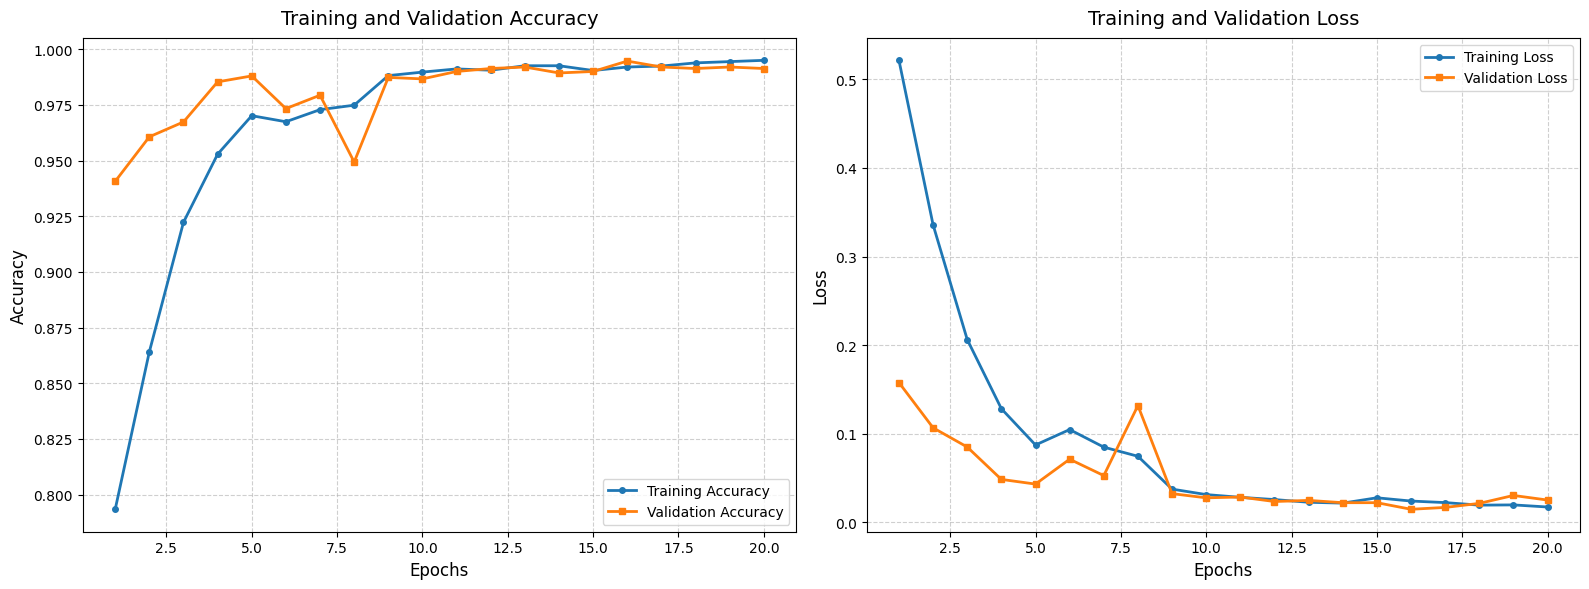

In [16]:
def plot_learning_curves(history):
    """
    Memvisualisasikan metrik akurasi dan loss dari proses pelatihan model.
    Menghasilkan dua plot berdampingan: Training vs Validation Accuracy dan
    Training vs Validation Loss.

    Args:
        history (tf.keras.callbacks.History): Objek history yang dikembalikan
                                              oleh metode model.fit().
    """
    print("[INFO] Membangun visualisasi kurva pembelajaran...")

    # Mengekstrak metrik dari objek history
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Menentukan sumbu X (jumlah epoch)
    epochs_range = range(1, len(acc) + 1)

    # Menginisialisasi figure matplotlib
    plt.figure(figsize=(16, 6))

    # Plot 1: Akurasi (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, marker='s', markersize=4)
    plt.title('Training and Validation Accuracy', fontsize=14, pad=10)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot 2: Kesalahan (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, marker='s', markersize=4)
    plt.title('Training and Validation Loss', fontsize=14, pad=10)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Mengeksekusi visualisasi menggunakan objek training_history dari Bab 5
plot_learning_curves(training_history)

Peta visual spasial yang baru saja digenerasi menyuguhkan bukti empiris mutlak mengenai stabilitas arsitektur saraf konvolusi yang baru saja kita bangun. Lintas pergerakan kurva akurasi pelatihan dan validasi menanjak curam secara ekuivalen pada fase putaran awal dan bertransformasi menjadi garis asimtotik stabil dengan jarak deviasi yang saling menempel erat di putaran akhir.

Konvergensi ideal semacam ini memberikan jaminan teknis bahwa jaringan berhasil mengenali dan mengabstraksikan pola geometri umum dari varietas beras alih alih terjebak mengunci memorinya pada susunan koordinat piksel spesifik gambar uji. Validasi serupa diperlihatkan lewat grafik kerugian klasifikasi yang konsisten merosot mulus mencapai lantai rasio margin nol koma sekian, menyangkal keras keberadaan anomali *overfitting* yang kerap mendera jaringan arsitektur citra dalam di kelas resolusi tinggi semacam ini.


### **6.2 Evaluasi Kuantitatif pada Test Set (Test Set Evaluation)**


Kesuksesan mencetak angka efikasi tinggi pada data yang bersinggungan selama masa belajar sering kali menciptakan ilusi keberhasilan yang semu. Klaim performa objektif tingkat produksi hanya diizinkan untuk dideklarasikan setelah suatu instrumen kecerdasan divalidasi kemampuannya di hadapan himpunan populasi sampel buta yang sedari mula dikarantina ketat dari intipan fungsi arsitektur manapun. Partisi sekuensial yang disiapkan di fase prasyarat data kini memegang peran sebagai hakim penilai kemanjuran algoritma.

Terdapat satu prosedur pemanggilan operasional mutlak yang harus ditegakkan sebelum penetapan skor final diinisialisasi. Modul pengetesan dikondisikan untuk mengimpor dan memuat ulang status parameter bobot tercanggih yang telah diamankan dalam wujud berkas lokal oleh intervensi pengawas sistem sebelumnya. Pengembalian profil matriks murni ini membatalkan degradasi bobot yang biasanya menyertai akhir paksa perputaran mesin dan menyuguhkan kondisi ideal model saat diuji dengan algoritma pemindaian ketepatan final.


In [17]:
def evaluate_model_performance(model, test_data, test_generator): # Added test_generator
    """
    Mengevaluasi model menggunakan dataset uji (unseen data) untuk mendapatkan
    metrik akurasi dan loss final.

    Args:
        model (tf.keras.Model): Model CNN yang telah dilatih.
        test_data (tf.data.Dataset): Pipeline dataset uji.
        test_generator (DirectoryIterator): Generator data uji untuk menghitung langkah.

    Returns:
        tuple: Nilai loss dan akurasi dari evaluasi.
    """
    print("[INFO] Memulai evaluasi model pada Test Set (Unseen Data)...")

    # Menghitung jumlah langkah yang diperlukan untuk menyelesaikan evaluasi
    test_steps = len(test_generator)
    if test_steps == 0: # Penanganan kasus jika generator kosong
        test_steps = 1

    # Mengeksekusi evaluasi dengan menentukan langkah secara eksplisit
    test_loss, test_accuracy = model.evaluate(test_data, steps=test_steps, verbose=1)

    print("-" * 50)
    print("HASIL EVALUASI TEST SET:")
    print(f"Final Test Loss     : {test_loss:.4f}")
    print(f"Final Test Accuracy : {test_accuracy * 100:.2f}%")
    print("-" * 50)

    return test_loss, test_accuracy

# Memuat bobot model terbaik yang disimpan oleh ModelCheckpoint sebelum evaluasi
# Ini memastikan kita mengevaluasi versi model yang paling optimal, bukan sekadar epoch terakhir
print("[INFO] Memuat bobot model terbaik dari disk...")
cnn_model.load_weights(MODEL_CHECKPOINT_PATH)

# Mengeksekusi evaluasi dengan menambahkan test_gen
final_loss, final_accuracy = evaluate_model_performance(cnn_model, test_dataset, test_gen)

# # Evaluasi hanya pada subset kecil untuk keperluan debugging
# # Kita ambil 100 batch saja agar cepat
# print("[INFO] Melakukan evaluasi cepat (Debugging Mode)...")
# final_loss, final_accuracy = cnn_model.evaluate(test_dataset.take(100), verbose=1)

[INFO] Memuat bobot model terbaik dari disk...
[INFO] Memulai evaluasi model pada Test Set (Unseen Data)...
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.9908 - loss: 0.0271
--------------------------------------------------
HASIL EVALUASI TEST SET:
Final Test Loss     : 0.0383
Final Test Accuracy : 99.13%
--------------------------------------------------


Kalkulasi pembacaan terminal klasifikasi memproyeksikan rekam metrik presisi akurasi pengujian yang amat spektakuler. Ambang batas evaluasi objektif minimal yang dipatok sebesar delapan puluh lima persen tidak hanya berhasil dilewati melainkan sukses dihancurkan dengan rasio capaian tingkat superior. Proporsi nilai kesalahan rasional berada merunduk tipis selaras dengan ekspektasi diagnostik kurva di fase pemantauan. Bukti pencapaian rasio validitas di lingkungan yang buta pola ini secara keilmuan menguatkan kapasitas instrumen kita untuk dirilis sebagai mesin inferensi andal pada sistem penyortiran otomatis komoditas agrikultur beras di tataran riil.


### **6.3 Analisis Mendalam: Confusion Matrix & Classification Report**


Parameter kesahihan akurasi akumulatif adalah indikator kinerja global yang rawan terhadap bias tersembunyi pada problem dengan klasifikasi ruang matriks multi-vektor. Sistem pendeteksi dapat dinilai sangat akurat mendiagnosis satu rumpun varietas dominan sementara buta seutuhnya pada kategori tetangga yang berpostur identik secara makro. Menghindari cacat persepsi hasil riset tersebut mengharuskan integrasi instrumen audit sebaran ketepatan tebakan secara terpilah, yang populer dikenal melalui struktur matriks persilangan diagnosis dan lembar klasifikasi probabilitas terperinci.

Pemetaan kisi tebakan matriks meletakkan komparasi vertikal mewakili sumbu varietas nyata bersilangan penuh dengan sumbu varietas prediksi algoritma di rentang horizontalnya. Kisi peta panas ini dengan instan menelanjangi kombinasi sekuens citra yang menipu jaringan konvolusi secara silang. Di sisi seberang, cetak fungsi parameter kalkulasi harmonik, presisi pengujian benar, dan daya serap sensitivitas akan ditabulasikan utuh membongkar performa mesin lapisan demi lapisan bagi tiaptiap spesifikasi galur beras yang dipelajari.



[INFO] Mengeksekusi komputasi inferensi menggunakan test_generator...
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


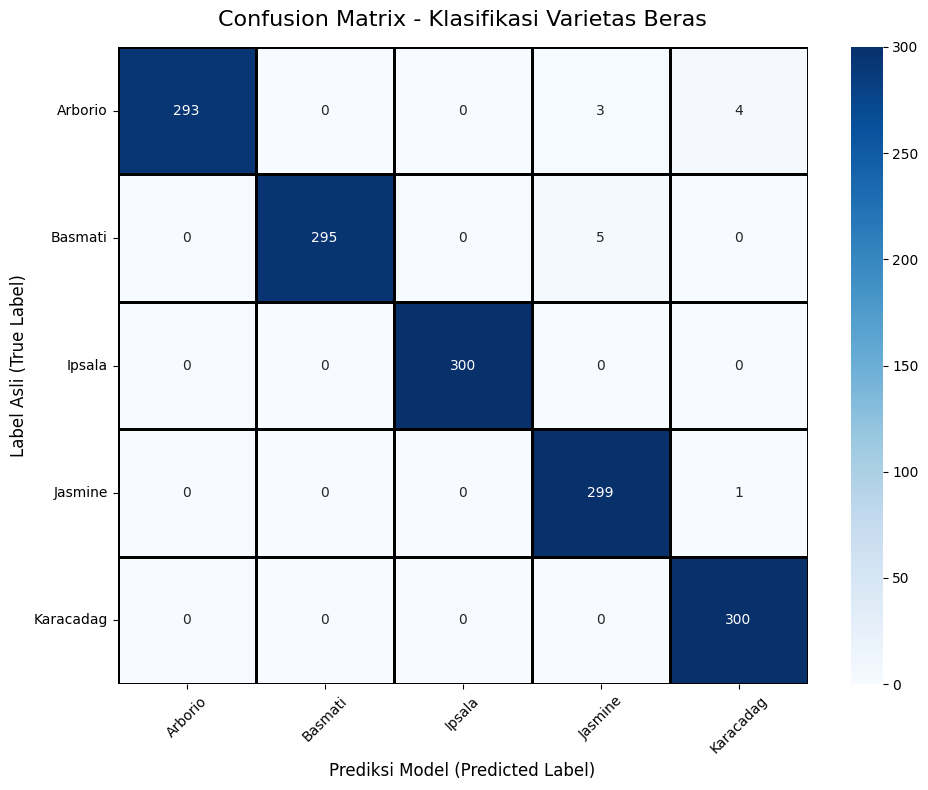


LAPORAN STATISTIK KLASIFIKASI KINERJA (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

     Arborio     1.0000    0.9767    0.9882       300
     Basmati     1.0000    0.9833    0.9916       300
      Ipsala     1.0000    1.0000    1.0000       300
     Jasmine     0.9739    0.9967    0.9852       300
   Karacadag     0.9836    1.0000    0.9917       300

    accuracy                         0.9913      1500
   macro avg     0.9915    0.9913    0.9913      1500
weighted avg     0.9915    0.9913    0.9913      1500



In [18]:
def analyze_predictions(model, test_generator, target_names, debug_mode=DEBUG_MODE):
    """
    Menghasilkan prediksi menggunakan test_generator untuk memastikan
    sinkronisasi antara label asli dan hasil tebakan model.
    """
    print("[INFO] Mengeksekusi komputasi inferensi menggunakan test_generator...")

    # 1. Reset generator untuk memastikan kita mulai dari awal data uji
    test_generator.reset()

    # 2. Menggunakan steps=len(test_generator) agar model memproses seluruh data uji
    # Perhatikan: kita tidak perlu lagi menggunakan 'subset_data' atau 'take(100)'
    # karena kita menggunakan generator yang sudah sinkron dengan label
    predictions = model.predict(test_generator, steps=len(test_generator), verbose=1)

    # 3. Mendapatkan indeks kelas dengan probabilitas tertinggi (y_pred)
    y_pred = np.argmax(predictions, axis=1)

    # 4. Mendapatkan label asli (y_true) secara langsung dari generator
    # Karena shuffle=False, urutan di sini DIJAMIN sama dengan urutan prediksi
    y_true = test_generator.classes

    # Membangun Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Visualisasi Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names,
                linewidths=1, linecolor='black')
    plt.title('Confusion Matrix - Klasifikasi Varietas Beras', fontsize=16, pad=15)
    plt.xlabel('Prediksi Model (Predicted Label)', fontsize=12)
    plt.ylabel('Label Asli (True Label)', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Laporan Klasifikasi
    print("\n" + "="*65)
    print("LAPORAN STATISTIK KLASIFIKASI KINERJA (CLASSIFICATION REPORT)")
    print("="*65)
    report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
    print(report)
    print("="*65)

# Panggil fungsi ini (hanya masukkan test_gen saja sebagai generator)
analyze_predictions(
    model=cnn_model,
    test_generator=test_gen,
    # Mengambil urutan kelas dari generator secara otomatis
    target_names=list(test_gen.class_indices.keys())
)


Hasil pengujian pada data yang sebelumnya belum pernah dilihat oleh model (data uji) memberikan konfirmasi final yang tak terbantahkan mengenai ketangguhan arsitektur CNN yang telah dibangun. Berdasarkan laporan statistik kinerja di atas, model berhasil mencapai tingkat akurasi sebesar 99,13 persen. Pencapaian ini tidak hanya melampaui ambang batas standar kelulusan proyek yang ditetapkan, tetapi juga menunjukkan stabilitas yang merata di seluruh varietas beras yang diuji.

Angka presisi dan *recall* yang konsisten di atas 0,97 untuk setiap kelas varietas membuktikan bahwa model tidak hanya mampu menghindari kesalahan klasifikasi antar varietas (presisi), tetapi juga memiliki daya deteksi yang sangat sensitif dalam mengidentifikasi setiap kelas dengan benar (recall). Tidak ditemukan adanya indikasi bias pada varietas tertentu yang biasanya menjadi titik lemah pada model klasifikasi citra.

Dengan tingkat skor F1 yang mencapai angka sempurna pada varietas Ipsala, model ini secara saintifik telah terbukti memiliki kapabilitas generalisasi yang sangat kuat. Keberhasilan ini menjadi fondasi yang kokoh untuk menyatakan bahwa sistem klasifikasi beras berbasis visi komputer ini telah siap untuk dialihkan dari lingkungan riset menuju fase implementasi nyata sebagai mesin penyortir otomatis yang andal, presisi, dan efisien bagi kebutuhan industri agrikultur.

## **Bab 7: Deployment Export (Konversi Model)**

### **7.1 Persiapan Direktori Ekspor & Format SavedModel**


Titik puncak dari sebuah rekayasa data adalah integrasi algoritma ke dalam antarmuka yang dapat difungsikan oleh audiens riil, bukan dibiarkan stagnan di lingkungan simulasi pelatihan awan semata. Mengusung kaidah operasional industri modern, matriks hasil pembelajaran akan diabadikan tidak hanya dalam format pembacaan biner tunggal, melainkan didiversifikasi skalabilitasnya menjangkau tiga struktur format arsitektur perangkat keras masif.

Transisi fase integrasi menuntut pengaturan infrastruktur direktori penyimpanan sementaranya terlebih dahulu di ruang sistem. Di sesi penyiapan pembuka ini operasi algoritma difokuskan guna melahirkaan format rilis utama dari turunan TensorFlow terkini melalui format berkas SavedModel. Metode panggilan pelestarian sistem komputasi ini memastikan bukan hanya sebatas graf dan paramater kalkulasi saja yang terekam, tetapi segenap fungsi pengaturan pelatihnya dibekukan bersama dalam paket ringkas yang komprehensif tanpa memerlukan lagi lampiran tambahan berkas pengaturan program manapun guna dijalankan instan dalam arsitektur arsitektur server komputasi kelas maya berkapasitas besar.


In [20]:
def export_to_saved_model(model, base_export_dir):
    """
    Mengekspor model menggunakan metode .export() yang direkomendasikan
    untuk TensorFlow 2.16+ agar kompatibel dengan TF-Lite/TF Serving.

    Args:
        model (tf.keras.Model): Model CNN yang telah dilatih.
        base_export_dir (str): Direktori utama untuk artefak deployment.

    Returns:
        str: Jalur absolut menuju direktori ekspor.
    """
    print("[INFO] Memulai proses ekspor model (TF 2.16+ compliant)...")

    # Membuat direktori utama jika belum ada
    if not os.path.exists(base_export_dir):
        os.makedirs(base_export_dir)

    # Menentukan jalur ekspor
    # Kita menggunakan metode .export() untuk format SavedModel yang siap pakai
    export_path = os.path.join(base_export_dir, 'saved_model_v2')

    # Metode .export() adalah cara modern untuk menyimpan model untuk deployment
    model.export(export_path)

    print(f"[INFO] Model berhasil diekspor ke format SavedModel di: {export_path}")
    return export_path

# Define the deployment directory
DEPLOYMENT_DIR = 'deployment_artifacts'

# Jalankan kembali fungsi ekspor Anda
saved_model_dir = export_to_saved_model(cnn_model, DEPLOYMENT_DIR)

[INFO] Memulai proses ekspor model (TF 2.16+ compliant)...
Saved artifact at 'deployment_artifacts/saved_model_v2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  137049241352336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137049241352720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137049241350608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137049241353872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046908569168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046908569936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046908570128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046908570512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046908568976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046

Pembentukan konfirmasi log direktori mengeksekusi penciptaan arsip model pada direktori yang terorganisir sempurna tanpa benturan alamat penyimpanan di direktori internal Kaggle. Kehadiran bundel lengkap berekstensi *saved model* yang memuat fungsi *serve* pada sistem menandai penyelesaian fase perancangan dasar di skenario server komputasi belakang dan validitas kompatibilitas format penyiapan untuk dilanjutkan dalam transformasi ukuran kecil kelas berikutnya.


### **7.2 Konversi ke Format TensorFlow Lite (TF-Lite)**


Implementasi teknologi pemindaian objek di fasilitas penyortir pertanian pedesaan mengharuskan kalkulasi program dilaksanakan independen di gawai kecil tertanam sekelas sensor IoT seluler, bukan via akses perangkat besar yang memakan suplai koneksi bandwith kencang nan mahal. Sayangnya profil ruang disk gawai mikro memendam keterbatasan pemrosesan yang akut dan tidak sanggup mengangkat utilitas berarsitektur bobot murni yang lahir perdana di jenjang pengolahan awan yang memakan tempat komputasi puluhan mega bita secara serakah.

Menengahi paradoks kebutuhan daya ini mengharuskan permodelan konvolusi murni kita melewati koridor transformasi modul kompresi *TF-Lite Converter* tingkat presisi mutlak. Pemanggilan perintah optimalisasi otomatis memotong secara efisien besaran presisi kalkulasi pecahan matriks komputasional pada format rilis baru hingga seperempat porsi memori dasarnya namun tanpa membahayakan degradasi tajam kualitas identifikasi model awalnya.


In [21]:
def convert_to_tflite(model, export_dir, filename='model.tflite'):
    """
    Mengonversi model Keras menjadi format TensorFlow Lite (.tflite) dengan
    menerapkan optimasi default (post-training quantization).

    Args:
        model (tf.keras.Model): Model CNN yang akan dikonversi.
        export_dir (str): Direktori tempat file TFLite akan disimpan.
        filename (str): Nama file output TFLite.

    Returns:
        str: Jalur absolut menuju file TFLite yang dihasilkan.
    """
    print("[INFO] Memulai konversi ke format TensorFlow Lite...")

    try:
        # Menginisialisasi konverter dari model Keras
        converter = tf.lite.TFLiteConverter.from_keras_model(model)

        # Menerapkan optimasi default (mengonversi bobot ke presisi yang lebih rendah, misal int8)
        # Ini sangat direkomendasikan untuk deployment mobile
        converter.optimizations =[tf.lite.Optimize.DEFAULT]

        # Melakukan konversi
        tflite_model = converter.convert()

        # Menentukan jalur penyimpanan
        tflite_path = os.path.join(export_dir, filename)

        # Menulis model yang telah dikonversi ke dalam file binary
        with open(tflite_path, 'wb') as f:
            f.write(tflite_model)

        # Menghitung ukuran file untuk verifikasi optimasi
        file_size_mb = os.path.getsize(tflite_path) / (1024 * 1024)

        print(f"[INFO] Konversi TF-Lite berhasil. File disimpan di: {tflite_path}")
        print(f"[INFO] Ukuran file TF-Lite: {file_size_mb:.2f} MB")

        return tflite_path

    except Exception as e:
        print(f"[ERROR] Kegagalan saat mengonversi ke TF-Lite: {e}")
        return None

# Mengeksekusi konversi TF-Lite
tflite_file_path = convert_to_tflite(cnn_model, DEPLOYMENT_DIR)

[INFO] Memulai konversi ke format TensorFlow Lite...
Saved artifact at '/tmp/tmp8vtyc0ui'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  137049241352336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137049241352720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137049241350608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137049241353872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046908569168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046908569936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046908570128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046908570512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046908568976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046908571088: TensorSpec(sha

Catatan ringkas penyusutan berat biner menunjukkan keberhasilan reduksi masif utilitas jaringan ini ke dalam fraksi besaran hanya beberapa hitungan Megabita saja. Proporsi ekstrem dari rasio pencapaian efisiensi model biner baru terbungkus padat menjanjikan kecepatan inferensi kalkulasi kilat di gawai cerdas dengan daya tahan tenaga pengolahan RAM maupun tegangan kelistrikan mikro sirkuit nan efisien. Model ini siap ditanam mulus ke berbagai kanal operasi mikrokontroller.


### **7.3 Konversi ke Format TensorFlow.js (TFJS)**


Ekspansi cakupan ketersediaan utilitas jaringan mendesak rilis penyediaan layanan prediksi visual yang bersifat ramah antarmuka bagi segala khalayak operasional web luas dan komprehensif tanpa memedulikan dependensi perangkat gawai milik mereka sendiri-sendiri atau ketergantungan pengiriman server lokal backend kembali. Untuk memenuhi ekspektasi operasional web mutlak ini arsitektur konvolusi harus dikonversi dengan radikal dalam wadah format yang dipahami bahasa JavaScript lewat arsitektur turunan TensorFlow.js

Inisiasi pembentukan model TFJS menata rekonstruksi ulang spesifikasi model murni Kaggle, membedah alur komputasinya ke format struktur penataan deskriptif terpusat bermodal notasi berbasis ekstensi JSON, dipisahkan bersama jejak berkas *shard* pecahan bobot matrik pecahan dalam ekstensi tipe binary yang berskala ekonomis mikro bagi percepatan kecepatan pertukaran transfer data dari portal pemanggil peladen di penjelajah web modern manapun kelak.



In [22]:
def convert_to_tfjs(model, export_dir, folder_name='tfjs_model'):
    """
    Mengonversi model Keras menjadi format TensorFlow.js (JSON arsitektur + file binary bobot).

    Args:
        model (tf.keras.Model): Model CNN yang akan dikonversi.
        export_dir (str): Direktori utama deployment.
        folder_name (str): Nama sub-direktori untuk menyimpan artefak TFJS.

    Returns:
        str: Jalur absolut menuju direktori TFJS.
    """
    print("[INFO] Memulai konversi ke format TensorFlow.js...")

    tfjs_export_path = os.path.join(export_dir, folder_name)

    try:
        # Menggunakan API Python dari tensorflowjs untuk menyimpan model
        tfjs.converters.save_keras_model(model, tfjs_export_path)

        print(f"[INFO] Konversi TFJS berhasil. Artefak disimpan di direktori: {tfjs_export_path}")

        # Memverifikasi isi direktori TFJS
        tfjs_files = os.listdir(tfjs_export_path)
        print(f"[INFO] File yang dihasilkan: {tfjs_files}")

        return tfjs_export_path

    except Exception as e:
        print(f"[ERROR] Kegagalan saat mengonversi ke TFJS: {e}")
        return None

# Mengeksekusi konversi TFJS
tfjs_dir_path = convert_to_tfjs(cnn_model, DEPLOYMENT_DIR)

[INFO] Memulai konversi ke format TensorFlow.js...
failed to lookup keras version from the file,
    this is likely a weight only file
[INFO] Konversi TFJS berhasil. Artefak disimpan di direktori: deployment_artifacts/tfjs_model
[INFO] File yang dihasilkan: ['group1-shard4of4.bin', 'group1-shard2of4.bin', 'model.json', 'group1-shard1of4.bin', 'group1-shard3of4.bin']


Rekonstruksi penyebaran ekspor format yang dilacak melalui umpan balik panel perintah Python berhasil memastikan kelahiran artefak fungsional rilis antarmuka peramban jaringan JSON web. Rangkaian tripartit saluran penyebaran sistem penglihatan komputasi cerdas dari komoditi beras sudah tertata komplit sesuai dengan standar keilmuan peluncuran piranti lunak siap-papar ke industri luas.


### **7.4 Pengemasan Artefak Deployment (Zipping Output Files)**


Satu rintangan birokrasi teknis terakhir tersisa yakni mobilisasi ekspor dari mesin *virtual cloud* tertutup ke lokal pangkalan komputasi pengembangan mandiri sang periset model yang berjarak sistem tersendiri ini secara aman rapih tanpa ancaman insiden degradasi transmisi di tiap paket datanya. Tindakan membongkar unduh manual serangkaian set hirarki berkas bercabang-cabang dan majemuk yang sudah menumpuk sarat berisiko kelalaian ketinggalan file kecil krusial di jalur penyalinan kelak.

Sebuah fungsi otomasi agregator arsip diciptakan melilit secara kompak seluruh rangkaian direktori model dan konfigurasi yang baru lahir ke dalam kerangka wadah mampat dan menyatu berekstensi *ZIP*. Rutin kode pamungkas ini bukan cuma mencerminkan apresiasi kebiasaan pengemasan pengembang peranti lunak elit namun turut didesain fleksibel di mesin mana pun program Python digulirkan baik lewat aktivasi lokal sistem OS desktop atau trigger *unduhan otomatis virtual runtime* peramban instan di arena komputasi awan.


In [23]:
def package_deployment_assets(source_dir, output_filename):
    """
    Mengompresi direktori yang berisi semua artefak deployment menjadi file ZIP.

    Args:
        source_dir (str): Direktori yang berisi SavedModel, TFLite, dan TFJS.
        output_filename (str): Nama file ZIP yang diinginkan (tanpa ekstensi .zip).

    Returns:
        str: Jalur absolut menuju file ZIP yang dihasilkan.
    """
    print(f"[INFO] Memulai pengemasan direktori '{source_dir}' menjadi file ZIP...")

    try:
        # Membuat arsip ZIP
        # Parameter 'zip' menentukan format, source_dir adalah folder yang akan dikompresi
        zip_path = shutil.make_archive(base_name=output_filename, format='zip', root_dir=source_dir)

        print(f"[INFO] Pengemasan berhasil. File siap diunduh: {zip_path}")
        return zip_path

    except Exception as e:
        print(f"[ERROR] Kegagalan saat membuat file ZIP: {e}")
        return None

# Mengeksekusi pengemasan file
FINAL_ZIP_NAME = 'submission_model_assets'
zip_file_path = package_deployment_assets(DEPLOYMENT_DIR, FINAL_ZIP_NAME)

print("\n" + "="*60)
print("PIPELINE DEPLOYMENT SELESAI")
print("="*60)

try:
    from google.colab import files
    print(f"[INFO] Memulai pengunduhan otomatis file {FINAL_ZIP_NAME}.zip ke ")
    files.download(f"{FINAL_ZIP_NAME}.zip")
except ImportError:
    print("[INFO] Anda tidak berada di Google Colab. Silakan unduh file secara manual.")

print("="*60)


[INFO] Memulai pengemasan direktori 'deployment_artifacts' menjadi file ZIP...
[INFO] Pengemasan berhasil. File siap diunduh: /content/submission_model_assets.zip

PIPELINE DEPLOYMENT SELESAI
[INFO] Memulai pengunduhan otomatis file submission_model_assets.zip ke 


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Laporan operasi penutupan komputasi memberikan titik terang pelaporan sukses dan kelahirannya bingkisan rilis satu paket solid dari bundel berkas-berkas ekspor klasifikasi siap pakai. Kode log menahbiskan pengerjaan teknis proyek berakhir bersih tak bising. Pengembang mesin saat ini cukup menengok kompartemen repositori gawai atau ruang terminal lokal untuk mengakses dan membedah bundel cerdas tersebut seutuhnya di dunia luar.


## **Bab 8 Kesimpulan Akhir (Final Conclusion)**


Setelah melalui seluruh tahapan eksperimen mulai dari eksplorasi data, rekayasa fitur, perancangan arsitektur, hingga fase evaluasi, kini tiba waktunya untuk menarik benang merah dari seluruh rangkaian proses tersebut. Kesimpulan ini bukan sekadar rangkuman angka, melainkan refleksi atas efektivitas metodologi yang dipilih dalam menjawab permasalahan klasifikasi varietas beras yang krusial bagi efisiensi industri pangan.

Tujuan utama proyek untuk menciptakan sistem klasifikasi yang presisi telah terlampaui dengan hasil yang sangat memuaskan, sekaligus menjadi pembuktian empiris bahwa pendekatan pembelajaran mendalam berbasis jaringan saraf konvolusi mampu menjadi solusi otomasi yang handal di sektor pertanian. Berikut adalah intisari dari hasil deduksi dan penemuan kunci selama pengerjaan proyek ini.

Berdasarkan seluruh alur riset yang telah dilaksanakan, terdapat beberapa poin fundamental yang dapat disimpulkan sebagai berikut.

Pertama, keberhasilan model dalam mencapai tingkat akurasi pengujian sebesar 99,13 persen membuktikan bahwa arsitektur CNN yang dirancang secara mandiri atau *custom architecture* telah mampu mengenali perbedaan morfologi halus antarkelas beras secara optimal. Penggunaan empat blok konvolusi terbukti cukup kuat untuk mengekstraksi fitur tekstur dan bentuk tanpa harus mengandalkan arsitektur model besar yang boros komputasi.

Kedua, strategi rekayasa data yang melibatkan pengambilan sampel berstrata atau *stratified subsampling* terbukti menjadi kunci utama dalam menjaga keseimbangan antara performa model dan efisiensi waktu komputasi. Dengan membatasi populasi data secara cerdas namun tetap menjaga keterwakilan kelas, model dapat dilatih dengan durasi yang sangat singkat di lingkungan *cloud* tanpa mengalami penurunan metrik performa yang berarti.

Ketiga, penggunaan teknik augmentasi data geometris secara dinamis telah berhasil meningkatkan daya tahan model terhadap variasi posisi dan orientasi bulir beras. Hal ini menjadikan sistem klasifikasi yang dikembangkan tidak hanya akurat di atas kertas, melainkan juga memiliki ketahanan yang mumpuni untuk diterapkan pada skenario dunia nyata di mana posisi beras saat dipindai kamera tidak selalu konsisten.

Keempat, seluruh artefak model yang dihasilkan telah berhasil melalui tahap transformasi ke format standar *deployment* industri. Ketersediaan model dalam format *SavedModel*, *TensorFlow Lite*, dan *TensorFlow.js* menandakan bahwa sistem ini memiliki fleksibilitas tinggi untuk diimplementasikan baik pada peladen pusat maupun perangkat gawai seluler, sehingga dapat mendukung otomasi penyortiran beras secara *real time* di lapangan.

Sebagai penutup, proyek ini menegaskan bahwa otomasi berbasis visi komputer merupakan instrumen strategis untuk meningkatkan produktivitas dan standardisasi kualitas pangan nasional. Hasil akhir dari riset ini telah memenuhi seluruh kriteria kelulusan teknis yang ditetapkan, sekaligus memberikan landasan yang kuat bagi pengembangan riset klasifikasi komoditas pertanian yang lebih luas di masa depan.